# Inputs

In [ ]:
import pandas as pd
import numpy as np
import altair as alt

## Dataset

In [ ]:
!gdown --id '1pqULCPNUfiZ1H9bvtahu2gJOBbHPnVMr' --output datos.csv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1pqULCPNUfiZ1H9bvtahu2gJOBbHPnVMr
From (redirected): https://drive.google.com/uc?id=1pqULCPNUfiZ1H9bvtahu2gJOBbHPnVMr&confirm=t&uuid=26b29be6-c006-4eb8-8bbf-58bdd84b5a30
To: /content/datos.csv
100% 1.55G/1.55G [00:12<00:00, 120MB/s]


In [ ]:
#https://drive.google.com/file/d/1pqULCPNUfiZ1O9ODFOtBUg_cR0j7s4rS/edit?gid=507069586#gid=507069586
#ID: 17nXNQBaf2gi1O9ODFOtBUg_cR0j7s4rS
df = pd.read_csv('datos.csv')

In [ ]:
df.shape

(3339047, 34)

In [ ]:
df.head(5)

,tipo_entidad,nombre_tipo_entidad,codigo_entidad,nombre_entidad,fecha_corte,tipo_de_persona,sexo,tama_o_de_empresa,tipo_de_cr_dito,tipo_de_garant_a,...,tasa_ponderada,mes,year,year_month,costo_credito,costo_credito_ponderado,cod_departamento,nombre_departamento,nombre_municipio,tipo_municipio
0,1,BC-ESTABLECIMIENTO BANCARIO,7,Bancolombia,2025-02-28,Natural,Femenino,Microempresa,Crédito productivo,Sin garantia,...,251.52,2,2025,2025-02,20.96,20.96,76.0,VALLE DEL CAUCA,TULUÁ,Ciudades y aglomeraciones
1,1,BC-ESTABLECIMIENTO BANCARIO,7,Bancolombia,2025-02-28,Natural,Femenino,Microempresa,Crédito productivo,Sin garantia,...,268.80,2,2025,2025-02,22.40,22.40,5.0,ANTIOQUIA,MEDELLÍN,Ciudades y aglomeraciones
2,1,BC-ESTABLECIMIENTO BANCARIO,7,Bancolombia,2025-02-28,Natural,Femenino,Microempresa,Crédito productivo,Sin garantia,...,354.48,2,2025,2025-02,29.54,29.54,5.0,ANTIOQUIA,BELLO,Ciudades y aglomeraciones
3,1,BC-ESTABLECIMIENTO BANCARIO,7,Bancolombia,2025-02-28,Natural,Femenino,Microempresa,Crédito productivo,Sin garantia,...,251.52,2,2025,2025-02,20.96,20.96,63.0,QUINDÍO,ARMENIA,Ciudades y aglomeraciones
4,1,BC-ESTABLECIMIENTO BANCARIO,7,Bancolombia,2025-02-28,Natural,Femenino,Microempresa,Crédito productivo,Sin garantia,...,354.48,2,2025,2025-02,29.54,29.54,76.0,VALLE DEL CAUCA,SANTIAGO DE CALI,Ciudades y aglomeraciones


In [ ]:
df.columns

Index(['tipo_entidad', 'nombre_tipo_entidad', 'codigo_entidad',
       'nombre_entidad', 'fecha_corte', 'tipo_de_persona', 'sexo',
       'tama_o_de_empresa', 'tipo_de_cr_dito', 'tipo_de_garant_a',
       'producto_de_cr_dito', 'plazo_de_cr_dito', 'tasa_efectiva_promedio',
       'margen_adicional_a_la', 'montos_desembolsados', 'numero_de_creditos',
       'grupo_etnico', 'antiguedad_de_la_empresa', 'tipo_de_tasa',
       'rango_monto_desembolsado', 'clase_deudor', 'codigo_ciiu',
       'cod_municipio', 'plazo_de_cr_dito_num', 'tasa_ponderada', 'mes',
       'year', 'year_month', 'costo_credito', 'costo_credito_ponderado',
       'cod_departamento', 'nombre_departamento', 'nombre_municipio',
       'tipo_municipio'],
      dtype='object')

In [ ]:
df['producto_de_cr_dito'].unique()

array(['Crédito productivo de mayor monto (sin recursos de redescuento)',
       'Crédito popular productivo urbano (sin recursos de redescuento)',
       'Crédito productivo rural (sin recursos de redescuento)',
       'Crédito popular productivo rural (sin recursos de redescuento)',
       'Crédito productivo urbano (sin recursos de redescuento)',
       'Crédito productivo urbano  (con recursos de redescuento)',
       'Crédito popular productivo urbano  (con recursos de redescuento)',
       'Crédito productivo rural  (con recursos de redescuento)',
       'Crédito productivo de mayor monto (con recursos de redescuento)',
       'Crédito popular productivo rural (con recursos de redescuento)'],
      dtype=object)

In [ ]:
df['producto_de_credito_red'] = df['producto_de_cr_dito'].replace({
    'Crédito productivo urbano (sin recursos de redescuento)': 'Crédito productivo urbano',
    'Crédito productivo urbano  (con recursos de redescuento)': 'Crédito productivo urbano',
    'Crédito productivo rural (sin recursos de redescuento)': 'Crédito productivo rural',
    'Crédito productivo rural  (con recursos de redescuento)': 'Crédito productivo rural',
    'Crédito popular productivo urbano (sin recursos de redescuento)': 'Crédito popular productivo urbano',
    'Crédito popular productivo urbano  (con recursos de redescuento)': 'Crédito popular productivo urbano',
    'Crédito popular productivo rural (sin recursos de redescuento)': 'Crédito popular productivo rural',
    'Crédito popular productivo rural (con recursos de redescuento)': 'Crédito popular productivo rural',
    'Crédito productivo de mayor monto (sin recursos de redescuento)': 'Crédito productivo de mayor monto',
    'Crédito productivo de mayor monto (con recursos de redescuento)': 'Crédito productivo de mayor monto',
})

<Axes: xlabel='producto_de_credito_red'>

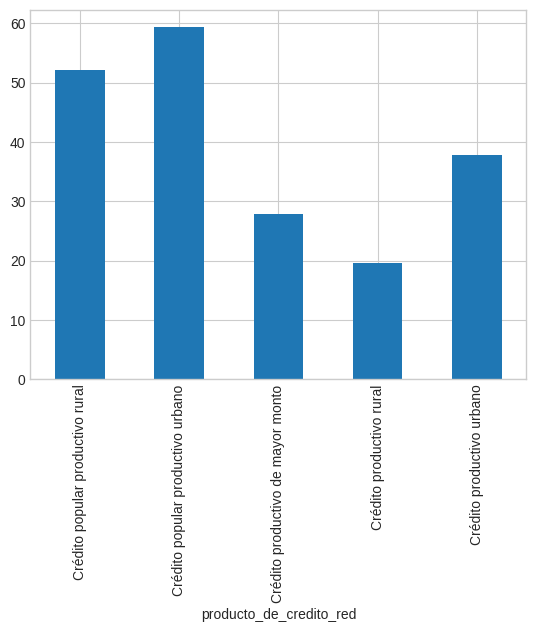

In [ ]:
df.groupby('producto_de_credito_red')['tasa_efectiva_promedio'].mean().plot.bar()

In [ ]:
grouped_by_producto_credito = df.groupby(['year_month', 'producto_de_credito_red']).agg(
    numero_de_creditos=('numero_de_creditos', 'sum'),
    montos_desembolsados=('montos_desembolsados', 'sum')
).reset_index()

monthly_totals = df.groupby('year_month').agg(
    total_numero_de_creditos=('numero_de_creditos', 'sum'),
    total_montos_desembolsados=('montos_desembolsados', 'sum')
).reset_index()

proportions_by_producto_credito_red = pd.merge(
    grouped_by_producto_credito,
    monthly_totals,
    on='year_month',
    how='left'
)

proportions_by_producto_credito_red['prop_numero_de_creditos'] = proportions_by_producto_credito_red['numero_de_creditos'] / proportions_by_producto_credito_red['total_numero_de_creditos']
proportions_by_producto_credito_red['prop_montos_desembolsados'] = proportions_by_producto_credito_red['montos_desembolsados'] / proportions_by_producto_credito_red['total_montos_desembolsados']

proportions_by_producto_credito_red.head()

,year_month,producto_de_credito_red,numero_de_creditos,montos_desembolsados,total_numero_de_creditos,total_montos_desembolsados,prop_numero_de_creditos,prop_montos_desembolsados
0,2023-09,Crédito popular productivo rural,3881,1.315892e+10,32474,3.026789e+11,0.119511,0.043475
1,2023-09,Crédito popular productivo urbano,15495,4.895419e+10,32474,3.026789e+11,0.477151,0.161736
2,2023-09,Crédito productivo de mayor monto,2052,9.248671e+10,32474,3.026789e+11,0.063189,0.305560
3,2023-09,Crédito productivo rural,3693,5.156090e+10,32474,3.026789e+11,0.113722,0.170349
4,2023-09,Crédito productivo urbano,7353,9.651817e+10,32474,3.026789e+11,0.226427,0.318880


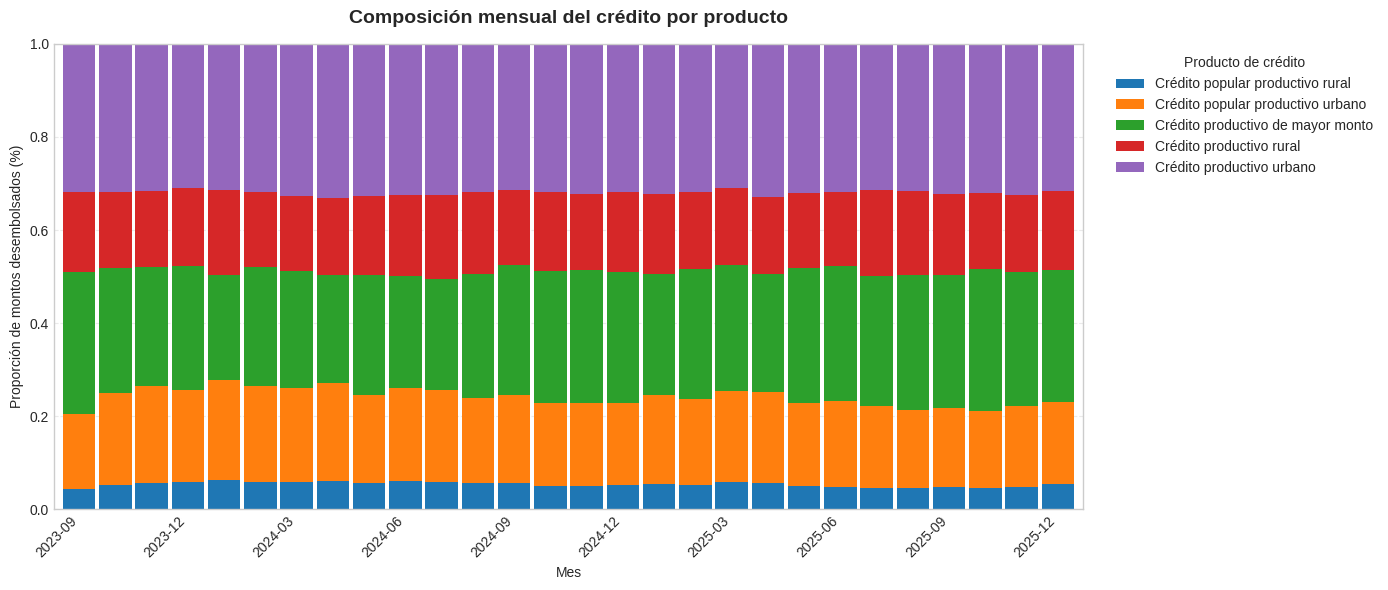

In [ ]:
import matplotlib.pyplot as plt

# 1) Pivot directo (NO volver a agregar proporciones)
pivot = (
    proportions_by_producto_credito_red
    .pivot_table(
        index="year_month",
        columns="producto_de_credito_red",
        values="prop_montos_desembolsados",
        aggfunc="mean"   # o 'sum' si sabes que no hay duplicados por mes-producto
    )
    .sort_index()
)

# 2) Plot barras apiladas
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(14, 6))

pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.9
)

# 3) Estilo académico
ax.set_title(
    "Composición mensual del crédito por producto",
    fontsize=14,
    weight="bold",
    pad=15
)
ax.set_xlabel("Mes")
ax.set_ylabel("Proporción de montos desembolsados (%)")
ax.set_ylim(0, 1)  # si está en [0,1]

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.grid(axis="x", visible=False)

# Submuestreo eje X
ax.set_xticks(range(len(pivot.index)))
ax.set_xticklabels(
    [m if i % 3 == 0 else "" for i, m in enumerate(pivot.index)],
    rotation=45,
    ha="right"
)

# Leyenda fuera
ax.legend(
    title="Producto de crédito",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


## Cálculo del IBC

In [ ]:
df.columns

Index(['tipo_entidad', 'nombre_tipo_entidad', 'codigo_entidad',
       'nombre_entidad', 'fecha_corte', 'tipo_de_persona', 'sexo',
       'tama_o_de_empresa', 'tipo_de_cr_dito', 'tipo_de_garant_a',
       'producto_de_cr_dito', 'plazo_de_cr_dito', 'tasa_efectiva_promedio',
       'margen_adicional_a_la', 'montos_desembolsados', 'numero_de_creditos',
       'grupo_etnico', 'antiguedad_de_la_empresa', 'tipo_de_tasa',
       'rango_monto_desembolsado', 'clase_deudor', 'codigo_ciiu',
       'cod_municipio', 'plazo_de_cr_dito_num', 'tasa_ponderada', 'mes',
       'year', 'year_month', 'costo_credito', 'costo_credito_ponderado',
       'cod_departamento', 'nombre_departamento', 'nombre_municipio',
       'tipo_municipio', 'producto_de_credito_red'],
      dtype='object')

In [ ]:
df['year_month'] = pd.to_datetime(df['fecha_corte']).dt.to_period('M')

In [ ]:
import numpy as np
import pandas as pd

def compute_ibc_series(
    df: pd.DataFrame,
    time_col: str = "year_month",
    rate_col: str = "tasa_efectiva_promedio",
    weight_col: str = "montos_desembolsados",
    where: dict | None = None,
) -> pd.DataFrame:
    """
    IBC proxy mensual = promedio ponderado de `rate_col` por `weight_col`,
    agrupando por `time_col` tal como viene en el dataset.

    - NO convierte fechas.
    - NO crea PeriodIndex.
    - Usa montos como pesos; si no hay, usa numero_de_creditos; si no, peso 1.
    - `where` permite filtrar por igualdad, p.ej. {"garantia_flag": 0}.
    """
    f = df.copy()

    # 1) Filtro opcional
    if where:
        for k, v in where.items():
            f = f.loc[f[k] == v]

    if f.empty:
        return pd.DataFrame(columns=[time_col, "IBC_proxy"])

    # 2) Pesos
    if weight_col in f.columns and f[weight_col].fillna(0).sum() > 0:
        f["_w"] = f[weight_col].astype(float)
    elif "numero_de_creditos" in f.columns and f["numero_de_creditos"].fillna(0).sum() > 0:
        f["_w"] = f["numero_de_creditos"].astype(float)
    else:
        f["_w"] = 1.0

    # 3) Promedio ponderado por mes
    ibc = (
        f.groupby(time_col)
         .apply(lambda g: np.average(g[rate_col].astype(float), weights=g["_w"]))
         .reset_index(name="IBC_proxy")
         .sort_values(time_col)
    )

    return ibc



In [ ]:
def ibc_gap_table(frame: pd.DataFrame,
                  time_col: str = "year_month",
                  rate_col: str = "tasa_efectiva_promedio",
                  weight_col: str = "montos_desembolsados") -> pd.DataFrame:
    """
    Construye una tabla con:
      - IBC_all
      - IBC_sin_garantia
      - IBC_con_garantia
      - IBC_rural_sin_garantia
      - gap_sin_garantia_%
    """

    f = frame.copy()

    # --- 1. Calcular cada serie por separado ---
    ibc_all = compute_ibc_series(f, time_col, rate_col, weight_col)
    ibc_all = ibc_all.rename(columns={"IBC_proxy": "IBC_all"})

    ibc_sin = compute_ibc_series(f, time_col, rate_col, weight_col,
                                 where={"garantia_flag": 0})
    ibc_sin = ibc_sin.rename(columns={"IBC_proxy": "IBC_sin_garantia"})

    ibc_con = compute_ibc_series(f, time_col, rate_col, weight_col,
                                 where={"garantia_flag": 1})
    ibc_con = ibc_con.rename(columns={"IBC_proxy": "IBC_con_garantia"})

    ibc_rural_sin = compute_ibc_series(f, time_col, rate_col, weight_col,
                                       where={"garantia_flag": 0, "rural_flag": 1})
    ibc_rural_sin = ibc_rural_sin.rename(columns={"IBC_proxy": "IBC_rural_sin_garantia"})

    # --- 2. Merge limpio (sin suffixes) ---
    out = ibc_all.merge(ibc_sin, on=time_col, how="outer")
    out = out.merge(ibc_con, on=time_col, how="outer")
    out = out.merge(ibc_rural_sin, on=time_col, how="outer")

    # --- 3. Gap porcentual ---
    out["gap_sin_garantia_%"] = (
        (out["IBC_sin_garantia"] - out["IBC_all"]) / out["IBC_all"] * 100
    )

    return out.sort_values(by=time_col)


In [ ]:
def weighted_mean(x: pd.Series, w: pd.Series) -> float:
    """Promedio ponderado, manejando nulos y pesos cero."""
    m = (~x.isna()) & (~w.isna())
    if m.sum() == 0 or w[m].sum() == 0:
        return np.nan
    return np.average(x[m].astype(float), weights=w[m].astype(float))

In [ ]:
def weighted_quantile(values: pd.Series, quantile: float, sample_weight: pd.Series) -> float:
    """
    Calcula el cuantil ponderado (por ejemplo, percentil 25 ponderado por montos).
    """
    v, w = np.array(values), np.array(sample_weight)
    m = (~np.isnan(v)) & (~np.isnan(w))
    if m.sum() == 0:
        return np.nan
    sorter = np.argsort(v[m])
    v, w = v[m][sorter], w[m][sorter]
    cum_w = np.cumsum(w)
    total = np.sum(w)
    return np.interp(quantile * total, cum_w, v)

In [ ]:
def _coalesce_weights(frame: pd.DataFrame,
                      weight_col: str = "montos_desembolsados",
                      fallback_weight_col: str = "numero_de_creditos") -> pd.Series:
    """Usa montos si existen; de lo contrario número de créditos; si ambos faltan, peso uniforme."""
    if weight_col in frame.columns and frame[weight_col].notna().any():
        w = frame[weight_col].astype(float).fillna(0.0)
        if w.sum() > 0:
            return w
    if fallback_weight_col in frame.columns and frame[fallback_weight_col].notna().any():
        w = frame[fallback_weight_col].astype(float).fillna(0.0)
        if w.sum() > 0:
            return w
    return pd.Series(1.0, index=frame.index)

In [ ]:
def low_rate_cohort_diagnostics(frame: pd.DataFrame,
                                q: float = 0.25,
                                time_col: str = "year_month",
                                rate_col: str = "tasa_efectiva_promedio",
                                weight_col: str = "montos_desembolsados") -> pd.DataFrame:
    """
    Para cada período (mes):
      - Calcula el cuantíl ponderado q (por defecto 25%) de la tasa.
      - Marca las filas con tasa <= a ese umbral como 'low_rate'.
      - Resume composición de esas tasas bajas: % con garantía, % rurales, tasa promedio.
    """
    f = frame.copy() # Initialize f

    # Defensive drop of potential temporary columns that might cause conflicts
    for temp_col in ['_period', '_period_temp']:
        if temp_col in f.columns:
            f = f.drop(columns=[temp_col])

    # Ensure time_col column exists and is in appropriate format for grouping.
    # The 'year_month' column is already prepared as PeriodIndex by a prior step.
    if time_col not in f.columns:
        if "fecha_corte" in f.columns:
            f[time_col] = pd.to_datetime(f["fecha_corte"], errors='coerce').dt.to_period("M")
        else:
            raise ValueError("No se encontró columna de tiempo. Usa 'year_month' o 'fecha_corte'.")

    # Only drop rows where time_col is NaT if necessary, but avoid re-conversion that might introduce them.
    # If 'year_month' is already PeriodDtype, this re-conversion might be problematic.
    # Assuming 'year_month' is already correctly formatted from 'fecha_corte' outside this function.
    f.dropna(subset=[time_col], inplace=True)

    # Ponderación: usa montos o número de créditos
    f["_w"] = _coalesce_weights(f, weight_col=weight_col, fallback_weight_col="numero_de_creditos")

    # Calcular umbral ponderado por período
    # Step 1: Group by time_col, which will make time_col the index
    grouped_f = f.groupby(time_col)
    # Step 2: Apply the weighted_quantile, resulting in a Series (expected) or DataFrame (observed)
    threshold_result = grouped_f.apply(lambda g: weighted_quantile(g[rate_col], q, g["_w"]))

    # Step 3: Ensure threshold_result is treated as a Series and convert to DataFrame explicitly
    if isinstance(threshold_result, pd.DataFrame):
        # If it's a DataFrame, assume it has one column for values and index for time_col
        # Take the first (and likely only) column of values to convert it to a Series
        threshold_series = threshold_result.iloc[:, 0]
    else:
        threshold_series = threshold_result # It's already a Series

    # Now, threshold_series should reliably be a Series. Create the DataFrame 'thresh' from it.
    thresh = pd.DataFrame({
        time_col: threshold_series.index,
        'threshold': threshold_series.values
    })

    f = f.merge(thresh, on=time_col, how="left")
    f["low_rate_flag"] = (f[rate_col] <= f["threshold"]).astype(int)

    # Resumir composición de las colocaciones de tasa baja
    def _agg(g):
        w = g["_w"]
        total_w = w.sum() if w.sum() > 0 else 1.0
        denom = w[g["low_rate_flag"] == 1].sum() or np.nan
        out = {
            "threshold_q": g["threshold"].iloc[0],
            "share_low_rate_%": 100.0 * w[g["low_rate_flag"] == 1].sum() / total_w,
            "rate_avg_low_rate": weighted_mean(g.loc[g["low_rate_flag"] == 1, rate_col], w[g["low_rate_flag"] == 1]),
            "share_garantia_low_rate_%": 100.0 * (w[(g["low_rate_flag"] == 1) & (g["garantia_flag"] == 1)].sum() / denom),
            "share_rural_low_rate_%": 100.0 * (w[(g["low_rate_flag"] == 1) & (g["rural_flag"] == 1)].sum() / denom),
        }
        return pd.Series(out)

    out = f.groupby(time_col, as_index=False).apply(_agg)
    return out

In [ ]:
def add_flags(frame: pd.DataFrame) -> pd.DataFrame:
    """
    Crea columnas binarias de identificación:
      - garantia_flag: 1 si el crédito tiene alguna garantía (FAG u otra), 0 si no.
      - rural_flag: 1 si el crédito pertenece a un municipio rural, 0 si no.

    Ajusta las condiciones según la codificación real de tu dataset.
    """
    f = frame.copy()

    # ------- Garantía -------
    col_g = "tipo_de_garant_a"
    if col_g in f.columns:
        g_str = f[col_g].astype(str).str.upper()
        # Marca 1 si NO dice 'SIN GARANT' o no está vacío
        has_g = (~f[col_g].isna()) & (~g_str.str.contains("FAG", na=False)) # <- agregar ~ y SIN GARANTIA
        f["garantia_flag"] = has_g.astype(int)
    else:
        f["garantia_flag"] = 0  # si no existe la columna, por defecto 0

    # ------- Ruralidad -------
    col_tm = "tipo_municipio"
    if col_tm in f.columns:
        # Cambiado a str.contains para incluir cadenas que contengan 'RURAL'
        f["rural_flag"] = f[col_tm].astype(str).str.upper().str.contains("RURAL", na=False).astype(int)
    else:
        f["rural_flag"] = np.nan  # sin información

    return f

In [ ]:
df = add_flags(df)

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df_credito_productivo = df.copy()

### Crédito Productivo

In [ ]:
gap = ibc_gap_table(df_credito_productivo, time_col="year_month",
                    rate_col="tasa_efectiva_promedio",
                    weight_col="numero_de_creditos")
# Columnas clave: IBC_all, IBC_sin_garantia, IBC_con_garantia, gap_sin_garantia_%
gap

/tmp/ipykernel_1002/2588240463.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[rate_col].astype(float), weights=g["_w"]))
/tmp/ipykernel_1002/2588240463.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[rate_col].astype(float), weights=g["_w"]))
/tmp/ipykernel_1002/2588240463.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the

,year_month,IBC_all,IBC_sin_garantia,IBC_con_garantia,IBC_rural_sin_garantia,gap_sin_garantia_%
0,2023-09,38.374467,10.959257,45.980756,10.679888,-71.441279
1,2023-10,40.991830,17.802456,46.767416,17.037598,-56.570721
2,2023-11,41.520697,19.219525,46.931100,18.353910,-53.710977
3,2023-12,40.890690,18.078739,46.767699,17.563619,-55.787639
4,2024-01,43.489279,15.903489,50.647204,15.622671,-63.431243
5,2024-02,45.994034,14.478289,51.924625,14.418793,-68.521376
6,2024-03,48.351957,14.090804,54.369948,14.076139,-70.857841
7,2024-04,48.738624,13.917240,54.734073,13.940264,-71.445153
8,2024-05,47.924233,13.748294,54.333644,13.679783,-71.312439
9,2024-06,49.057936,13.327339,55.330611,13.217149,-72.833471


In [ ]:
diag = low_rate_cohort_diagnostics(df_credito_productivo, q=0.25,  # cambiar a 0.20 o 0.30
                                   time_col="year_month",
                                   rate_col="tasa_efectiva_promedio",
                                   weight_col="montos_desembolsados")
# reporta: umbral (threshold_q), % peso low-rate, % con garantía dentro de low-rate, % rural, etc.

/tmp/ipykernel_1002/1973752244.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  threshold_result = grouped_f.apply(lambda g: weighted_quantile(g[rate_col], q, g["_w"]))
/tmp/ipykernel_1002/1973752244.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = f.groupby(time_col, as_index=False).apply(_agg)


In [ ]:
diag

,year_month,threshold_q,share_low_rate_%,rate_avg_low_rate,share_garantia_low_rate_%,share_rural_low_rate_%
0,2023-09,15.240000,25.119658,8.143692,6.479853,33.924145
1,2023-10,15.540000,25.421348,11.684333,5.629807,34.679761
2,2023-11,15.430000,25.357388,14.218047,5.734546,34.343080
3,2023-12,15.150000,25.296289,13.650407,5.973898,34.593724
4,2024-01,14.700000,25.248230,14.378091,5.717074,34.592668
5,2024-02,14.663570,24.999642,14.293162,7.183348,32.945472
6,2024-03,18.280000,25.129409,13.683708,12.332227,31.826320
7,2024-04,18.240000,25.607386,13.430955,9.902627,32.399129
8,2024-05,17.890000,25.241679,12.890922,12.666416,32.533142
9,2024-06,17.550000,25.423715,12.812926,12.876290,32.669349


#### Plots

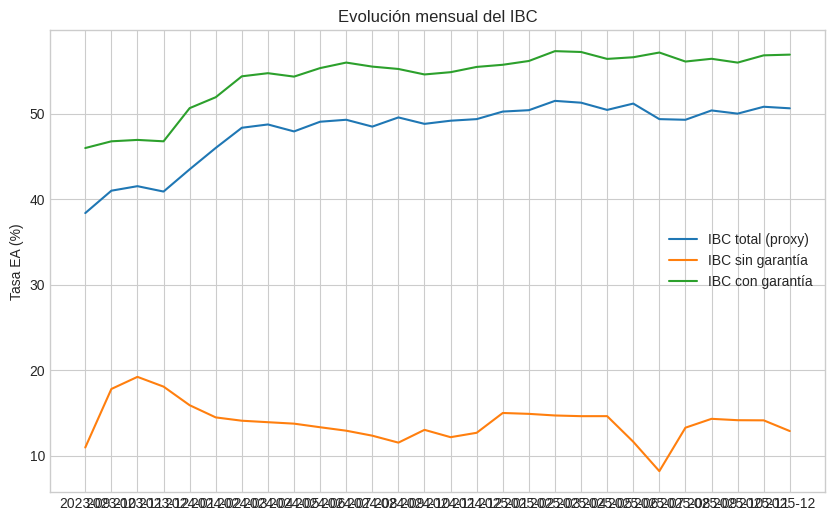

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

gap['year_month'] = gap['year_month'].astype(str)

plt.figure(figsize=(10,6))
plt.plot(gap["year_month"], gap["IBC_all"], label="IBC total (proxy)")
plt.plot(gap["year_month"], gap["IBC_sin_garantia"], label="IBC sin garantía")
plt.plot(gap["year_month"], gap["IBC_con_garantia"], label="IBC con garantía")
plt.legend()
plt.ylabel("Tasa EA (%)")
plt.title("Evolución mensual del IBC")
plt.show()

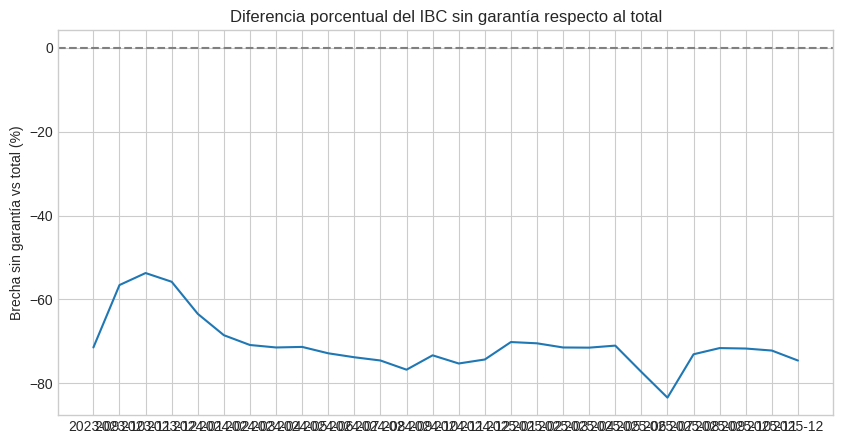

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(gap["year_month"], gap["gap_sin_garantia_%"])
plt.axhline(0, color="gray", linestyle="--")
plt.ylabel("Brecha sin garantía vs total (%)")
plt.title("Diferencia porcentual del IBC sin garantía respecto al total")
plt.show()

In [ ]:
share_g = (
    df_credito_productivo.groupby("year_month")
      .apply(lambda g: np.average(g["garantia_flag"], weights=g["montos_desembolsados"]))
      .reset_index(name="share_con_garantia")
)


/tmp/ipykernel_1002/4196579195.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["garantia_flag"], weights=g["montos_desembolsados"]))


In [ ]:
share_g

,year_month,share_con_garantia
0,2023-09,0.687091
1,2023-10,0.712438
2,2023-11,0.704729
3,2023-12,0.693571
4,2024-01,0.678275
5,2024-02,0.745428
6,2024-03,0.745948
7,2024-04,0.742242
8,2024-05,0.737226
9,2024-06,0.748115


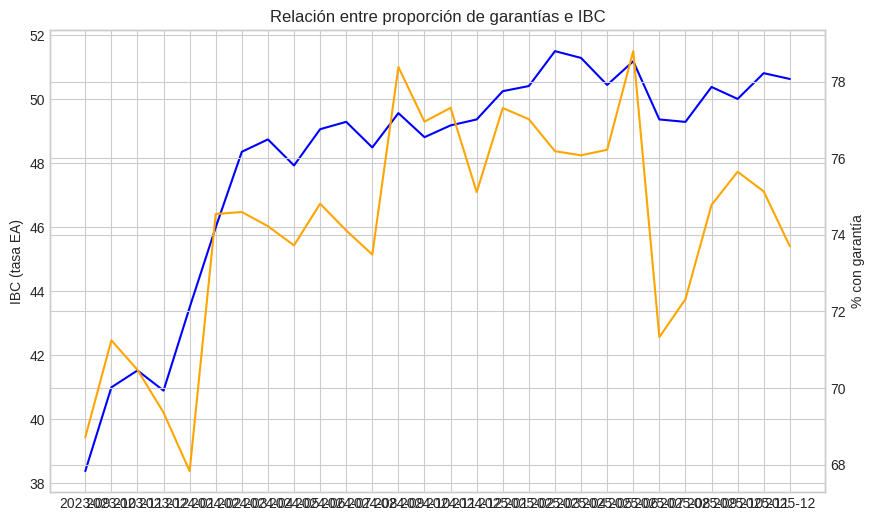

In [ ]:
share_g['year_month'] = share_g['year_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(10,6))
ax1.plot(gap["year_month"], gap["IBC_all"], label="IBC total", color="blue")
ax2 = ax1.twinx()
ax2.plot(share_g["year_month"], share_g["share_con_garantia"]*100, color="orange", label="% con garantía")
ax1.set_ylabel("IBC (tasa EA)"); ax2.set_ylabel("% con garantía")
plt.title("Relación entre proporción de garantías e IBC")
plt.show()

/tmp/ipykernel_1002/3569435467.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.ylabel("% del cohort"); plt.title("Composición del cohort de tasas bajas")


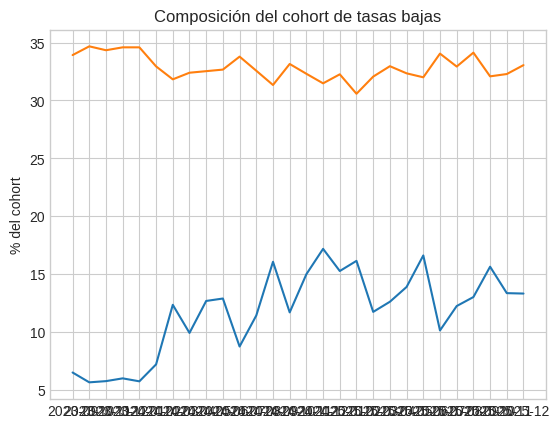

In [ ]:
diag['year_month'] = diag['year_month'].astype(str)

plt.plot(diag["year_month"], diag["share_garantia_low_rate_%"])
plt.plot(diag["year_month"], diag["share_rural_low_rate_%"])
plt.legend(); plt.ylabel("% del cohort"); plt.title("Composición del cohort de tasas bajas")
plt.show()

In [ ]:
df['producto_de_credito_red'].unique()

array(['Crédito productivo de mayor monto',
       'Crédito popular productivo urbano', 'Crédito productivo rural',
       'Crédito popular productivo rural', 'Crédito productivo urbano'],
      dtype=object)

<Axes: xlabel='year_month'>

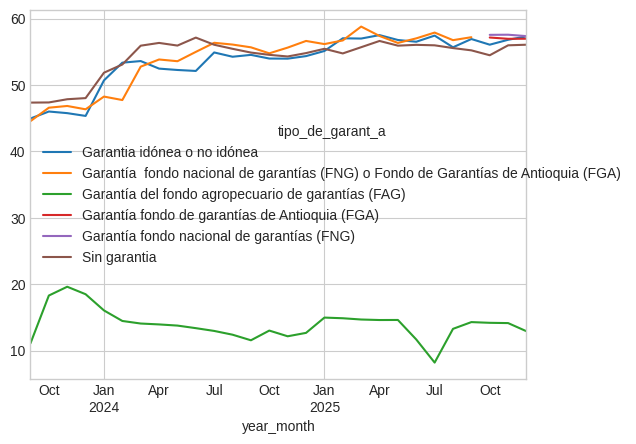

In [ ]:
#plot the avg tasa_efectiva_promedio per year_month, splitting by tipo_de_garant_a
df_credito_productivo.groupby(['year_month', 'tipo_de_garant_a'])['tasa_efectiva_promedio'].mean().unstack().plot()


<Axes: xlabel='year_month'>

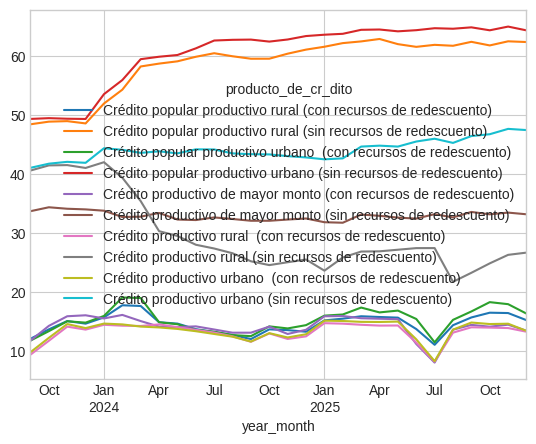

In [ ]:
df.groupby(['year_month', 'producto_de_cr_dito'])['tasa_efectiva_promedio'].mean().unstack().plot()

### Crédito Productivo Rural

In [ ]:
df_productivo_rural = df_credito_productivo[df_credito_productivo['producto_de_credito_red'] == 'Crédito productivo rural']

In [ ]:
gap_productivo_rural = ibc_gap_table(df_productivo_rural, time_col="year_month",
                    rate_col="tasa_efectiva_promedio",
                    weight_col="montos_desembolsados")
# Columnas clave: IBC_all, IBC_sin_garantia, IBC_con_garantia, gap_sin_garantia_%
gap_productivo_rural

/tmp/ipykernel_1002/2588240463.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[rate_col].astype(float), weights=g["_w"]))
/tmp/ipykernel_1002/2588240463.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[rate_col].astype(float), weights=g["_w"]))
/tmp/ipykernel_1002/2588240463.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the

,year_month,IBC_all,IBC_sin_garantia,IBC_con_garantia,IBC_rural_sin_garantia,gap_sin_garantia_%
0,2023-09,16.214316,9.653357,38.367890,9.658344,-40.463991
1,2023-10,19.440295,12.423609,39.372181,12.436682,-36.093515
2,2023-11,21.380454,15.069177,39.059200,15.076625,-29.518909
3,2023-12,20.456055,14.503138,38.757019,14.506779,-29.101000
4,2024-01,20.785115,14.723353,39.909184,14.727003,-29.163956
5,2024-02,21.416802,14.359649,37.688729,14.363294,-32.951480
6,2024-03,20.702724,14.326628,33.826872,14.332616,-30.798344
7,2024-04,19.477333,14.483094,29.386105,14.493904,-25.641290
8,2024-05,18.890163,14.029381,28.439517,14.037360,-25.731815
9,2024-06,18.448321,13.579732,27.190785,13.595146,-26.390415


In [ ]:
diag_productivo_rural = low_rate_cohort_diagnostics(df_productivo_rural, q=0.25,  # cambia a 0.20 o 0.30 si prefieres
                                   time_col="year_month",
                                   rate_col="tasa_efectiva_promedio",
                                   weight_col="montos_desembolsados")
# reporta: umbral (threshold_q), % peso low-rate, % con garantía dentro de low-rate, % rural, etc.


/tmp/ipykernel_1002/1973752244.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  threshold_result = grouped_f.apply(lambda g: weighted_quantile(g[rate_col], q, g["_w"]))
/tmp/ipykernel_1002/1973752244.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = f.groupby(time_col, as_index=False).apply(_agg)


In [ ]:
share_g_productivo_rural = (
    df_productivo_rural.groupby("year_month")
      .apply(lambda g: np.average(g["garantia_flag"], weights=g["montos_desembolsados"]))
      .reset_index(name="share_con_garantia")
)

/tmp/ipykernel_1002/3981091080.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["garantia_flag"], weights=g["montos_desembolsados"]))


#### Plots

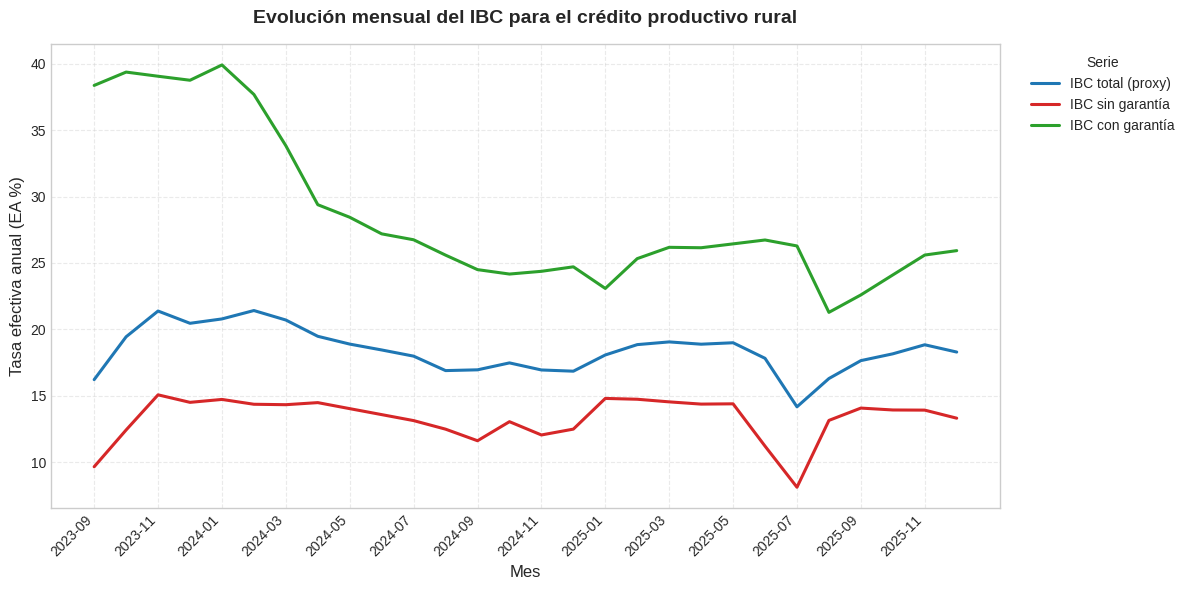

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Copia local
df = gap_productivo_rural.copy()

# Asegurar que year_month sea representable en eje X
df["year_month"] = df["year_month"].astype(str)

# Paleta sobria estilo académico
colors = {
    "IBC_all": "#1f77b4",         # azul
    "IBC_sin": "#d62728",         # rojo
    "IBC_con": "#2ca02c",         # verde
}

plt.style.use("seaborn-v0_8-whitegrid")  # whitegrid minimalista

fig, ax = plt.subplots(figsize=(12, 6))

# Líneas más gruesas
ax.plot(df["year_month"], df["IBC_all"], label="IBC total (proxy)",
        color=colors["IBC_all"], linewidth=2.2)
ax.plot(df["year_month"], df["IBC_sin_garantia"], label="IBC sin garantía",
        color=colors["IBC_sin"], linewidth=2.2)
ax.plot(df["year_month"], df["IBC_con_garantia"], label="IBC con garantía",
        color=colors["IBC_con"], linewidth=2.2)

# Rotación del eje X
plt.xticks(rotation=45, ha="right")

# Título y labels
ax.set_title("Evolución mensual del IBC para el crédito productivo rural", fontsize=14, weight="bold", pad=15)
ax.set_ylabel("Tasa efectiva anual (EA %)", fontsize=12)
ax.set_xlabel("Mes", fontsize=12)

# Grid más suave
ax.grid(which="major", linestyle="--", alpha=0.4)

# Ajuste de ticks para que no se vean saturados
ax.set_xticks(df["year_month"][::2])  # cada 2 meses (ajusta según necesidad)

# Leyenda fuera del área para mayor claridad
ax.legend(title="Serie", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


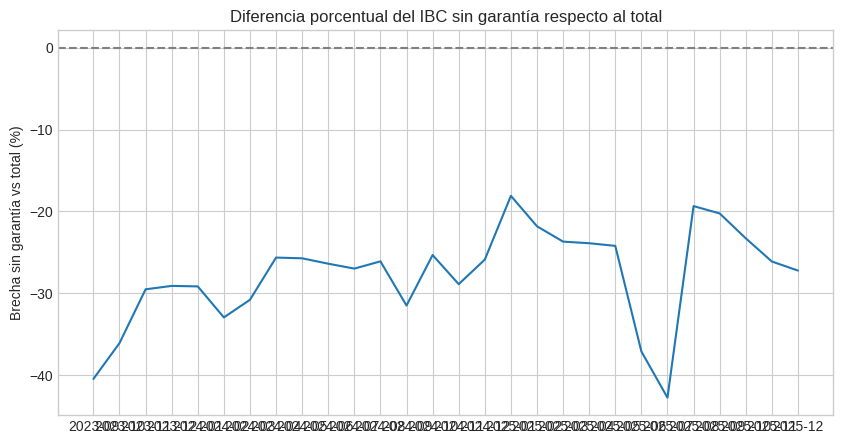

In [ ]:
import matplotlib.pyplot as plt

gap_productivo_rural['year_month'] = gap_productivo_rural['year_month'].astype(str)

plt.figure(figsize=(10,5))
plt.plot(gap_productivo_rural["year_month"], gap_productivo_rural["gap_sin_garantia_%"])
plt.axhline(0, color="gray", linestyle="--")
plt.ylabel("Brecha sin garantía vs total (%)")
plt.title("Diferencia porcentual del IBC sin garantía respecto al total")
plt.show()

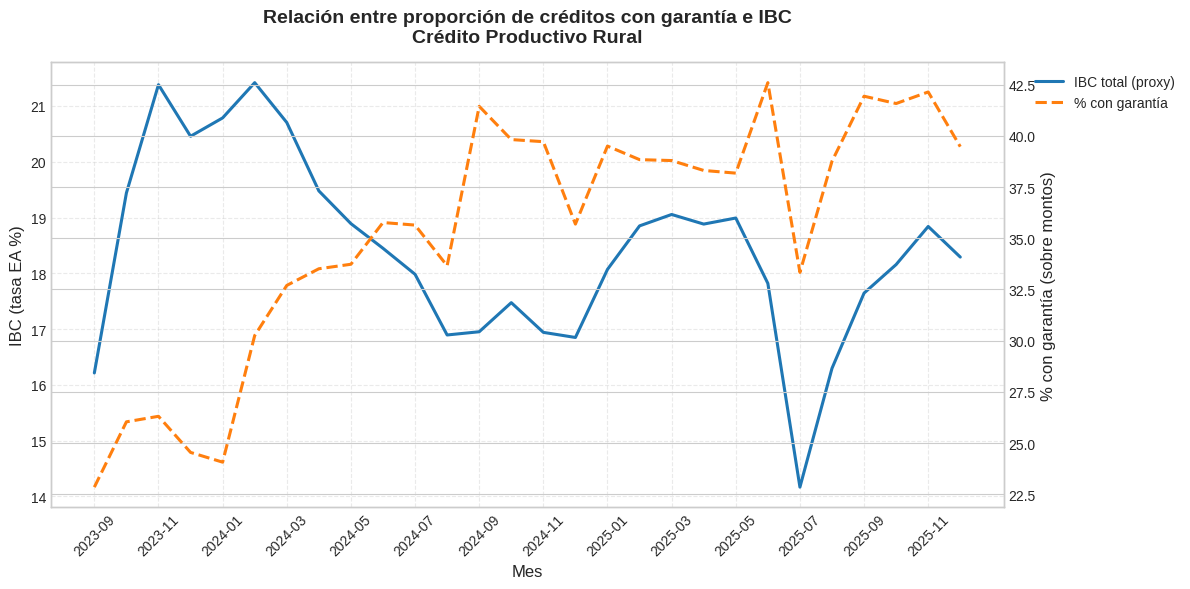

In [ ]:
import matplotlib.pyplot as plt

# Copias limpias
share = share_g_productivo_rural.copy()
gap = gap_productivo_rural.copy()

share["year_month"] = share["year_month"].astype(str)
gap["year_month"] = gap["year_month"].astype(str)

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

# Color palette (sobria y consistente)
color_ibc = "#1f77b4"       # azul
color_share = "#ff7f0e"     # naranja

# --- Serie IBC (eje izquierdo) ---
ax1.plot(
    gap["year_month"],
    gap["IBC_all"],
    color=color_ibc,
    linewidth=2.2,
    label="IBC total (proxy)"
)

ax1.set_ylabel("IBC (tasa EA %)", fontsize=12)
ax1.set_xlabel("Mes", fontsize=12)
ax1.tick_params(axis="x", rotation=45)

# Grid suave
ax1.grid(which="major", linestyle="--", alpha=0.4)

# Submuestreo para no saturar el eje X
ax1.set_xticks(gap["year_month"][::2])

# --- Serie % con garantía (eje derecho) ---
ax2 = ax1.twinx()

ax2.plot(
    share["year_month"],
    share["share_con_garantia"] * 100,
    color=color_share,
    linewidth=2.2,
    linestyle="--",
    label="% con garantía"
)

ax2.set_ylabel("% con garantía (sobre montos)", fontsize=12)

# --- Título ---
ax1.set_title(
    "Relación entre proporción de créditos con garantía e IBC\nCrédito Productivo Rural",
    fontsize=14,
    weight="bold",
    pad=15
)

# --- Leyenda conjunta fuera del área ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


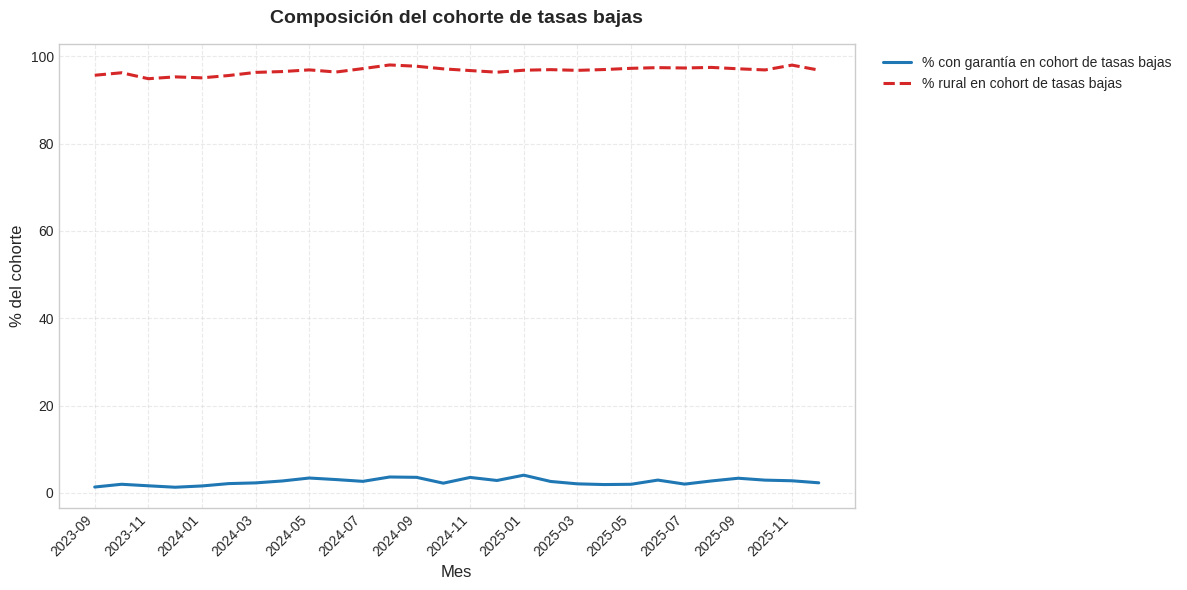

In [ ]:
import matplotlib.pyplot as plt

# Copia limpia
diag = diag_productivo_rural.copy()
diag["year_month"] = diag["year_month"].astype(str)

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

# Colores sobrios
color_garantia = "#1f77b4"   # azul
color_rural    = "#d62728"   # rojo

# Líneas
ax.plot(
    diag["year_month"],
    diag["share_garantia_low_rate_%"],
    color=color_garantia,
    linewidth=2.2,
    label="% con garantía en cohort de tasas bajas"
)

ax.plot(
    diag["year_month"],
    diag["share_rural_low_rate_%"],
    color=color_rural,
    linewidth=2.2,
    linestyle="--",
    label="% rural en cohort de tasas bajas"
)

# Labels y estilo
ax.set_title(
    "Composición del cohorte de tasas bajas",
    fontsize=14,
    weight="bold",
    pad=15
)

ax.set_ylabel("% del cohorte", fontsize=12)
ax.set_xlabel("Mes", fontsize=12)

plt.xticks(rotation=45, ha="right")
ax.grid(which="major", linestyle="--", alpha=0.4)

# Reducir densidad del eje X
ax.set_xticks(diag["year_month"][::2])

# Leyenda externa
ax.legend(
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


In [ ]:
diag_productivo_rural

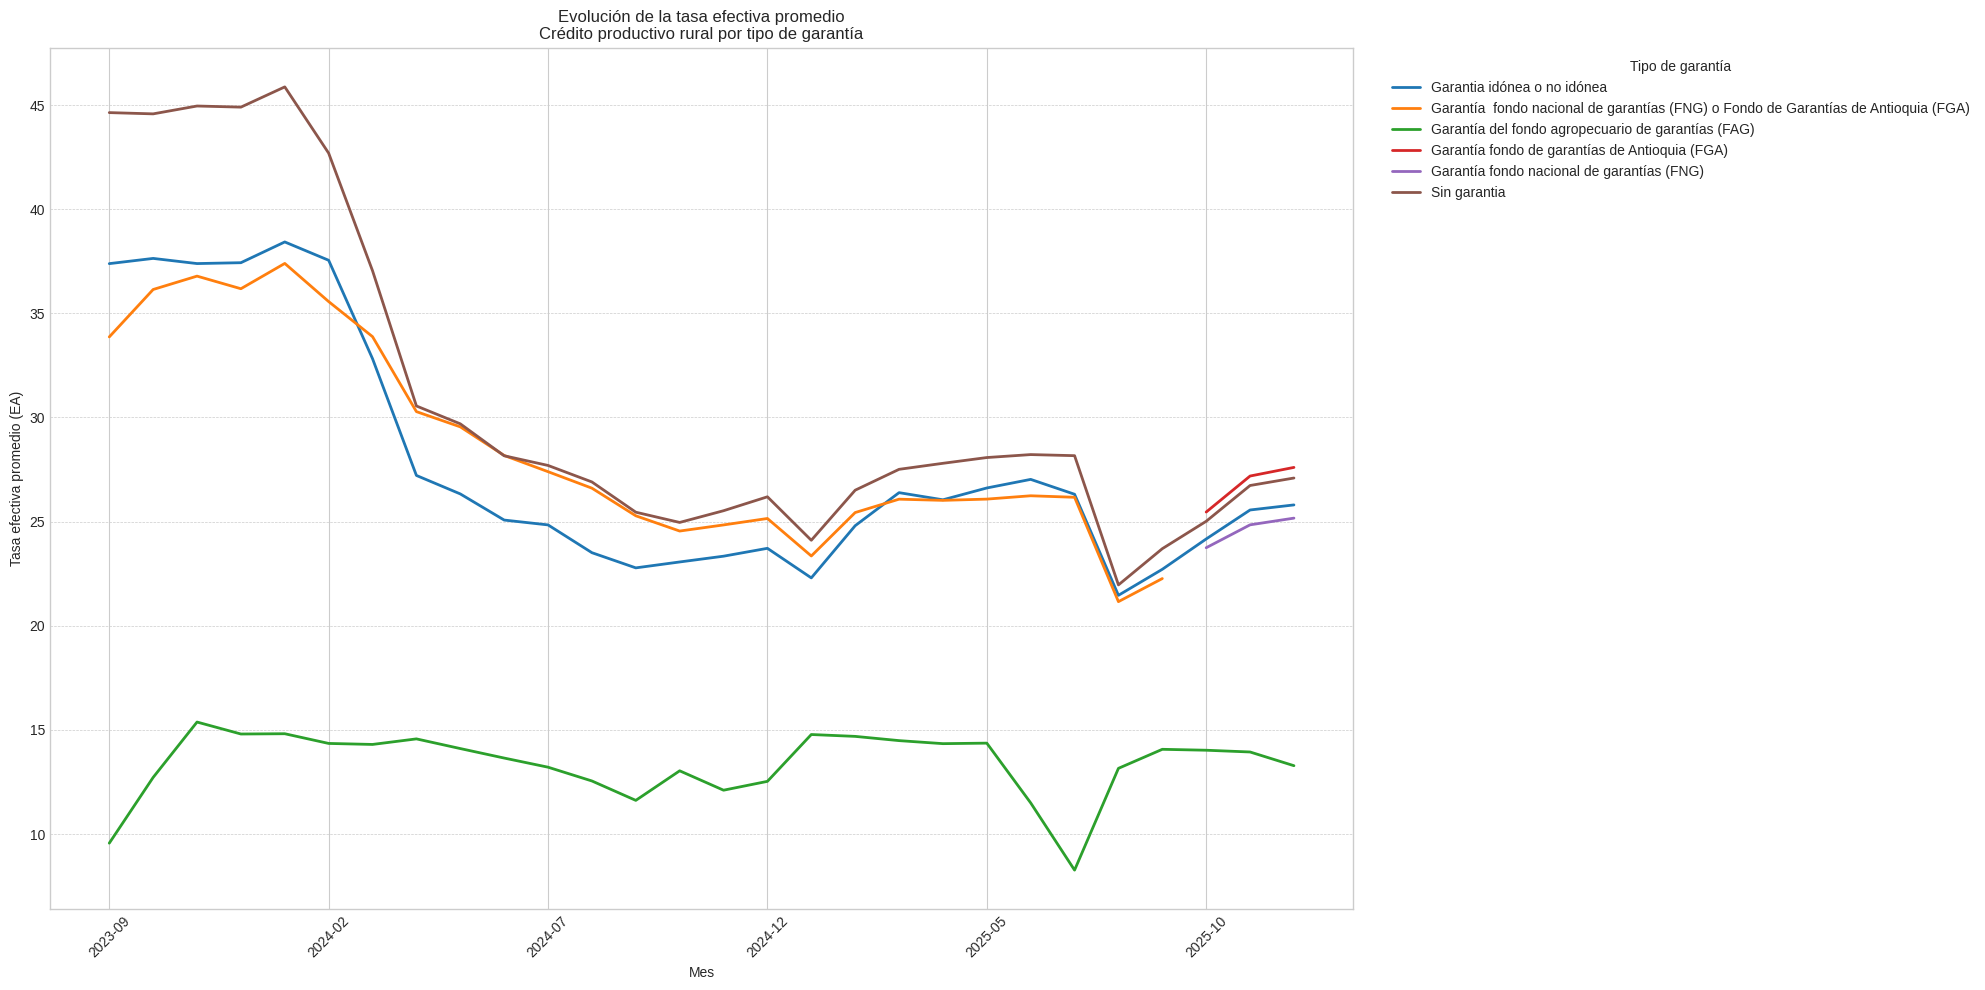

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Asegurar que year_month sea algo dibujable: YYYY-MM como string
df_productivo_rural = df_productivo_rural.copy()
df_productivo_rural["year_month_str"] = df_productivo_rural["year_month"].astype(str)

# Pivot: filas = mes, columnas = tipo de garantía
pivot = (
    df_productivo_rural
    .groupby(["year_month_str", "tipo_de_garant_a"])["tasa_efectiva_promedio"]
    .mean()
    .unstack()                    # columnas = tipos de garantía
    .sort_index()                 # ordenar cronológicamente
)

# Plot académico con matplotlib
fig, ax = plt.subplots(figsize=(20, 10))

pivot.plot(ax=ax, linewidth=2)

ax.set_title("Evolución de la tasa efectiva promedio\nCrédito productivo rural por tipo de garantía")

ax.set_xlabel("Mes")
ax.set_ylabel("Tasa efectiva promedio (EA)")
ax.grid(True, which="both", axis="y", linestyle="--", linewidth=0.5)

plt.xticks(rotation=45)

# LEYENDA
ax.legend(title="Tipo de garantía", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


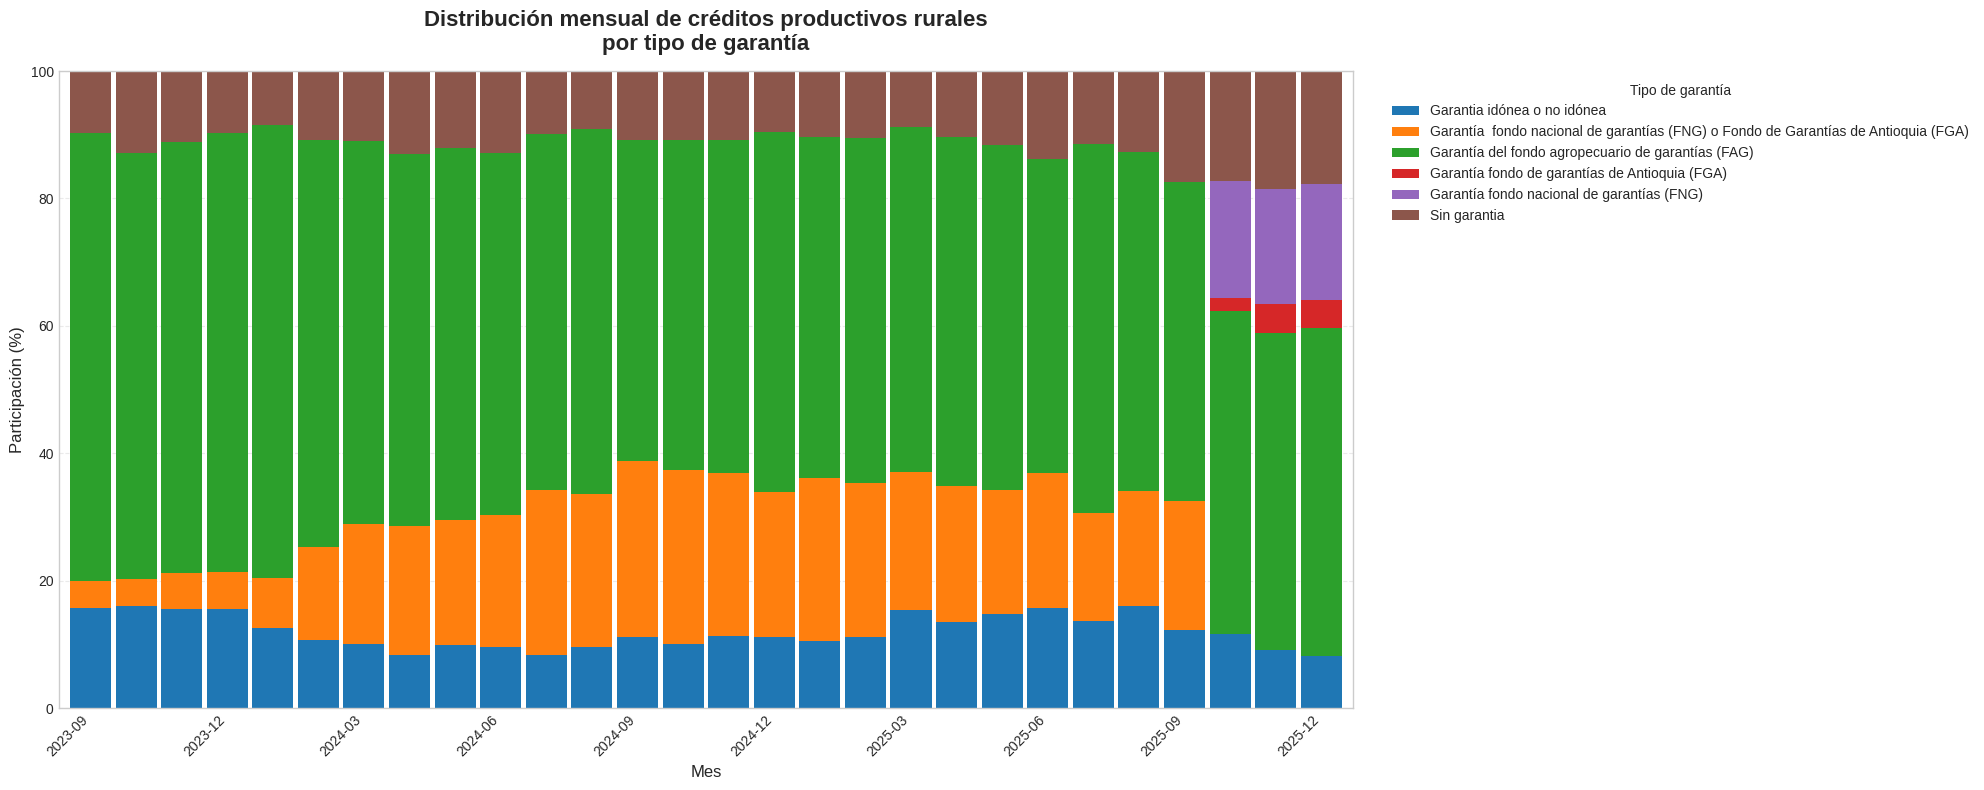

In [ ]:
import matplotlib.pyplot as plt

# Copia limpia
df = df_productivo_rural.copy()
df["year_month_str"] = df["year_month"].astype(str)

# 1) Conteo por mes y tipo de garantía
counts = (
    df.groupby(["year_month_str", "tipo_de_garant_a"])
      .size()
      .reset_index(name="n")
)

# 2) Pivot: filas = mes, columnas = tipo de garantía
pivot = (
    counts.pivot(index="year_month_str",
                 columns="tipo_de_garant_a",
                 values="n")
          .fillna(0)
          .sort_index()
)

# 3) Normalizar al 100% por mes
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# 4) Plot barras apiladas
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(20, 8))

proportions.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.9
)

# 5) Estética académica
ax.set_title(
    "Distribución mensual de créditos productivos rurales\npor tipo de garantía",
    fontsize=16,
    weight="bold",
    pad=15
)

ax.set_xlabel("Mes", fontsize=12)
ax.set_ylabel("Participación (%)", fontsize=12)

# Eje Y fijo 0–100
ax.set_ylim(0, 100)

# Grid solo horizontal
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.grid(axis="x", visible=False)

# Submuestreo eje X (cada 3 meses)
xticks = proportions.index[::3]
ax.set_xticks(range(len(proportions.index)))
ax.set_xticklabels(
    [m if m in xticks else "" for m in proportions.index],
    rotation=45,
    ha="right"
)

# Leyenda fuera
ax.legend(
    title="Tipo de garantía",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Crédito Productivo Popular Rural

In [ ]:
df_productivo_popular_rural = df_credito_productivo[df_credito_productivo['producto_de_credito_red'] == 'Crédito popular productivo rural']

In [ ]:
gap_productivo_popular_rural = ibc_gap_table(df_productivo_popular_rural, time_col="year_month",
                    rate_col="tasa_efectiva_promedio",
                    weight_col="montos_desembolsados")
# Columnas clave: IBC_all, IBC_sin_garantia, IBC_con_garantia, gap_sin_garantia_%
gap_productivo_popular_rural

/tmp/ipykernel_1002/2588240463.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[rate_col].astype(float), weights=g["_w"]))
/tmp/ipykernel_1002/2588240463.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[rate_col].astype(float), weights=g["_w"]))
/tmp/ipykernel_1002/2588240463.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the

,year_month,IBC_all,IBC_sin_garantia,IBC_con_garantia,IBC_rural_sin_garantia,gap_sin_garantia_%
0,2023-09,36.890994,12.907117,48.027894,12.900081,-65.012825
1,2023-10,40.191978,20.596173,48.627832,20.611217,-48.755513
2,2023-11,40.924432,20.659530,48.720522,20.654172,-49.517857
3,2023-12,40.387986,20.243180,48.300940,20.159494,-49.878213
4,2024-01,42.694873,16.469901,51.687549,16.431733,-61.424170
5,2024-02,44.771044,14.436503,53.379682,14.439389,-67.754822
6,2024-03,47.793053,13.829578,56.857801,13.830091,-71.063622
7,2024-04,48.973434,13.509873,57.241394,13.514755,-72.413874
8,2024-05,48.804216,13.616588,57.740160,13.622790,-72.099566
9,2024-06,50.182999,13.180565,58.796564,13.170332,-73.734999


In [ ]:
diag_productivo_popular_rural = low_rate_cohort_diagnostics(df_productivo_popular_rural, q=0.25,  # cambia a 0.20 o 0.30 si prefieres
                                   time_col="year_month",
                                   rate_col="tasa_efectiva_promedio",
                                   weight_col="montos_desembolsados")
# reporta: umbral (threshold_q), % peso low-rate, % con garantía dentro de low-rate, % rural, etc.


/tmp/ipykernel_1002/1973752244.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  threshold_result = grouped_f.apply(lambda g: weighted_quantile(g[rate_col], q, g["_w"]))
/tmp/ipykernel_1002/1973752244.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = f.groupby(time_col, as_index=False).apply(_agg)


In [ ]:
share_g_productivo_popular_rural = (
    df_productivo_popular_rural.groupby("year_month")
      .apply(lambda g: np.average(g["garantia_flag"], weights=g["montos_desembolsados"]))
      .reset_index(name="share_con_garantia")
)


/tmp/ipykernel_1002/79603150.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["garantia_flag"], weights=g["montos_desembolsados"]))


#### Plots

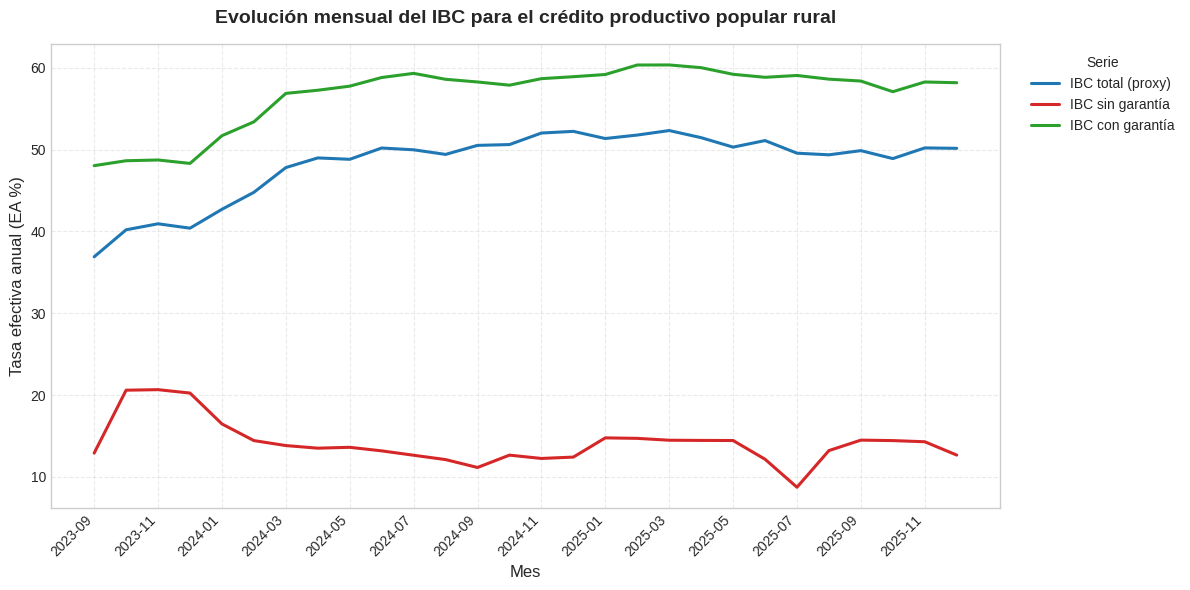

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Copia local
df = gap_productivo_popular_rural.copy()

# Asegurar que year_month sea representable en eje X
df["year_month"] = df["year_month"].astype(str)

# Paleta sobria estilo académico
colors = {
    "IBC_all": "#1f77b4",         # azul
    "IBC_sin": "#d62728",         # rojo
    "IBC_con": "#2ca02c",         # verde
}

plt.style.use("seaborn-v0_8-whitegrid")  # whitegrid minimalista

fig, ax = plt.subplots(figsize=(12, 6))

# Líneas más gruesas
ax.plot(df["year_month"], df["IBC_all"], label="IBC total (proxy)",
        color=colors["IBC_all"], linewidth=2.2)
ax.plot(df["year_month"], df["IBC_sin_garantia"], label="IBC sin garantía",
        color=colors["IBC_sin"], linewidth=2.2)
ax.plot(df["year_month"], df["IBC_con_garantia"], label="IBC con garantía",
        color=colors["IBC_con"], linewidth=2.2)

# Rotación del eje X
plt.xticks(rotation=45, ha="right")

# Título y labels
ax.set_title("Evolución mensual del IBC para el crédito productivo popular rural", fontsize=14, weight="bold", pad=15)
ax.set_ylabel("Tasa efectiva anual (EA %)", fontsize=12)
ax.set_xlabel("Mes", fontsize=12)

# Grid más suave
ax.grid(which="major", linestyle="--", alpha=0.4)

# Ajuste de ticks para que no se vean saturados
ax.set_xticks(df["year_month"][::2])  # cada 2 meses (ajusta según necesidad)

# Leyenda fuera del área para mayor claridad
ax.legend(title="Serie", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

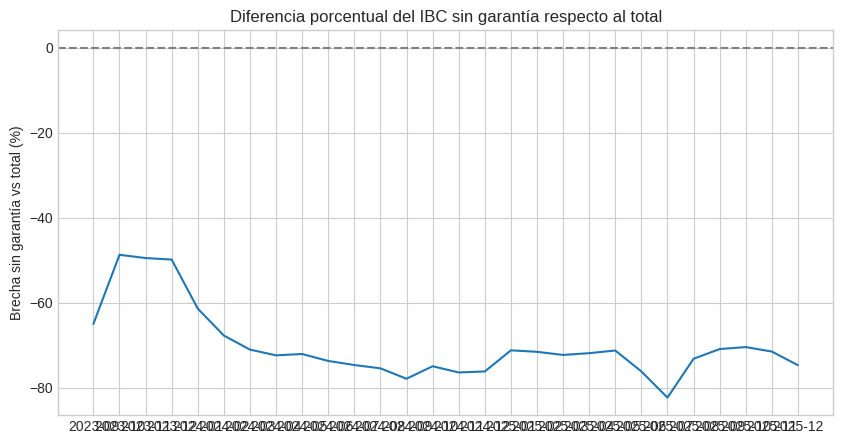

In [ ]:
import matplotlib.pyplot as plt

gap_productivo_popular_rural['year_month'] = gap_productivo_popular_rural['year_month'].astype(str)

plt.figure(figsize=(10,5))
plt.plot(gap_productivo_popular_rural["year_month"], gap_productivo_popular_rural["gap_sin_garantia_%"])
plt.axhline(0, color="gray", linestyle="--")
plt.ylabel("Brecha sin garantía vs total (%)")
plt.title("Diferencia porcentual del IBC sin garantía respecto al total")
plt.show()

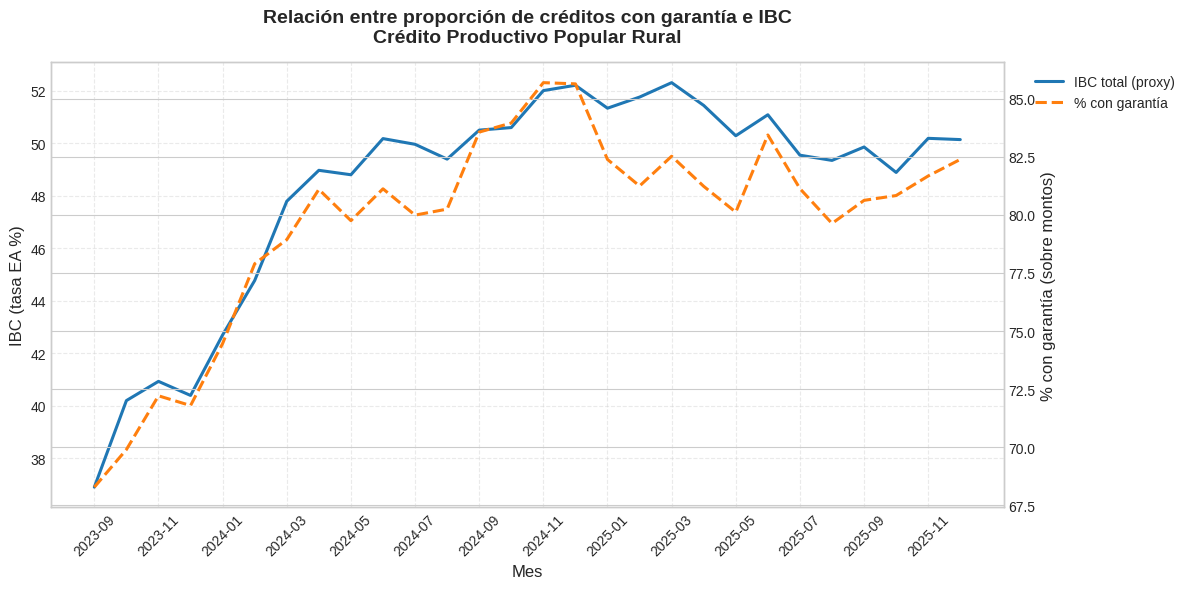

In [ ]:
import matplotlib.pyplot as plt

# Copias limpias
share = share_g_productivo_popular_rural.copy()
gap = gap_productivo_popular_rural.copy()

share["year_month"] = share["year_month"].astype(str)
gap["year_month"] = gap["year_month"].astype(str)

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

# Color palette (sobria y consistente)
color_ibc = "#1f77b4"       # azul
color_share = "#ff7f0e"     # naranja

# --- Serie IBC (eje izquierdo) ---
ax1.plot(
    gap["year_month"],
    gap["IBC_all"],
    color=color_ibc,
    linewidth=2.2,
    label="IBC total (proxy)"
)

ax1.set_ylabel("IBC (tasa EA %)", fontsize=12)
ax1.set_xlabel("Mes", fontsize=12)
ax1.tick_params(axis="x", rotation=45)

# Grid suave
ax1.grid(which="major", linestyle="--", alpha=0.4)

# Submuestreo para no saturar el eje X
ax1.set_xticks(gap["year_month"][::2])

# --- Serie % con garantía (eje derecho) ---
ax2 = ax1.twinx()

ax2.plot(
    share["year_month"],
    share["share_con_garantia"] * 100,
    color=color_share,
    linewidth=2.2,
    linestyle="--",
    label="% con garantía"
)

ax2.set_ylabel("% con garantía (sobre montos)", fontsize=12)

# --- Título ---
ax1.set_title(
    "Relación entre proporción de créditos con garantía e IBC\nCrédito Productivo Popular Rural",
    fontsize=14,
    weight="bold",
    pad=15
)

# --- Leyenda conjunta fuera del área ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


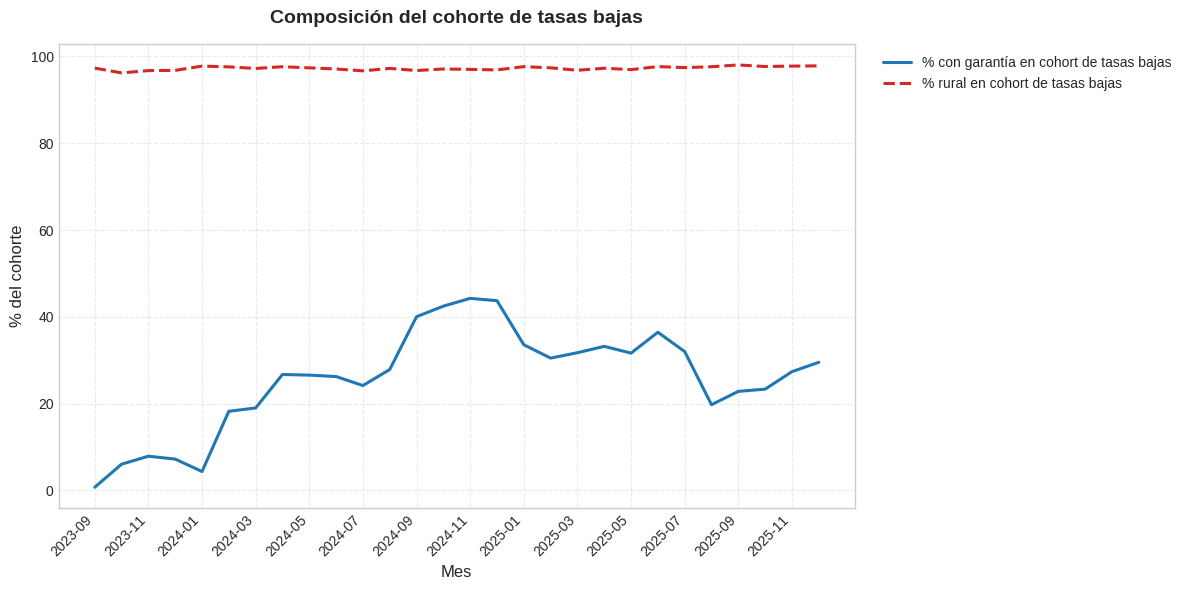

In [ ]:
import matplotlib.pyplot as plt

# Copia limpia
diag = diag_productivo_popular_rural.copy()
diag["year_month"] = diag["year_month"].astype(str)

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

# Colores sobrios
color_garantia = "#1f77b4"   # azul
color_rural    = "#d62728"   # rojo

# Líneas
ax.plot(
    diag["year_month"],
    diag["share_garantia_low_rate_%"],
    color=color_garantia,
    linewidth=2.2,
    label="% con garantía en cohort de tasas bajas"
)

ax.plot(
    diag["year_month"],
    diag["share_rural_low_rate_%"],
    color=color_rural,
    linewidth=2.2,
    linestyle="--",
    label="% rural en cohort de tasas bajas"
)

# Labels y estilo
ax.set_title(
    "Composición del cohorte de tasas bajas",
    fontsize=14,
    weight="bold",
    pad=15
)

ax.set_ylabel("% del cohorte", fontsize=12)
ax.set_xlabel("Mes", fontsize=12)

plt.xticks(rotation=45, ha="right")
ax.grid(which="major", linestyle="--", alpha=0.4)

# Reducir densidad del eje X
ax.set_xticks(diag["year_month"][::2])

# Leyenda externa
ax.legend(
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


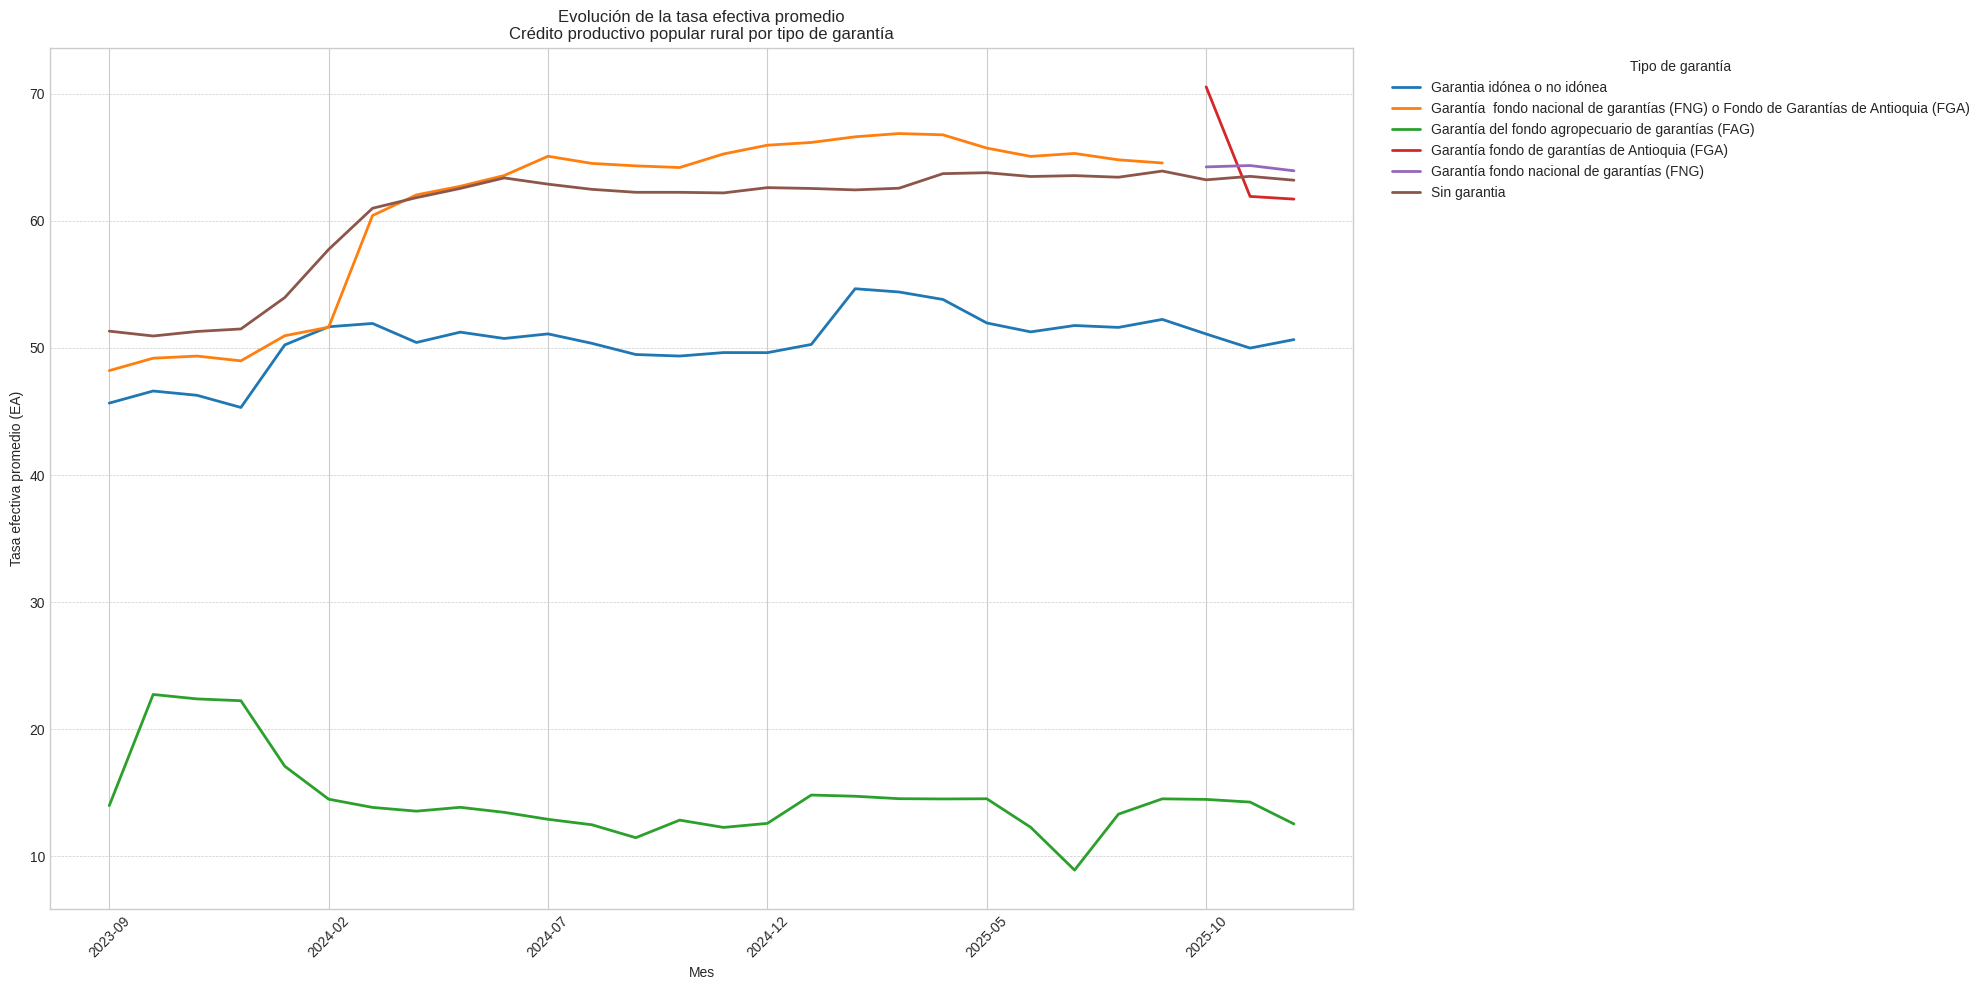

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Asegurar que year_month sea algo dibujable: YYYY-MM como string
df_productivo_popular_rural = df_productivo_popular_rural.copy()
df_productivo_popular_rural["year_month_str"] = df_productivo_popular_rural["year_month"].astype(str)

# Pivot: filas = mes, columnas = tipo de garantía
pivot = (
    df_productivo_popular_rural
    .groupby(["year_month_str", "tipo_de_garant_a"])["tasa_efectiva_promedio"]
    .mean()
    .unstack()                    # columnas = tipos de garantía
    .sort_index()                 # ordenar cronológicamente
)

# Plot académico con matplotlib
fig, ax = plt.subplots(figsize=(20, 10))

pivot.plot(ax=ax, linewidth=2)

ax.set_title("Evolución de la tasa efectiva promedio\nCrédito productivo popular rural por tipo de garantía")

ax.set_xlabel("Mes")
ax.set_ylabel("Tasa efectiva promedio (EA)")
ax.grid(True, which="both", axis="y", linestyle="--", linewidth=0.5)

plt.xticks(rotation=45)

# LEYENDA
ax.legend(title="Tipo de garantía", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

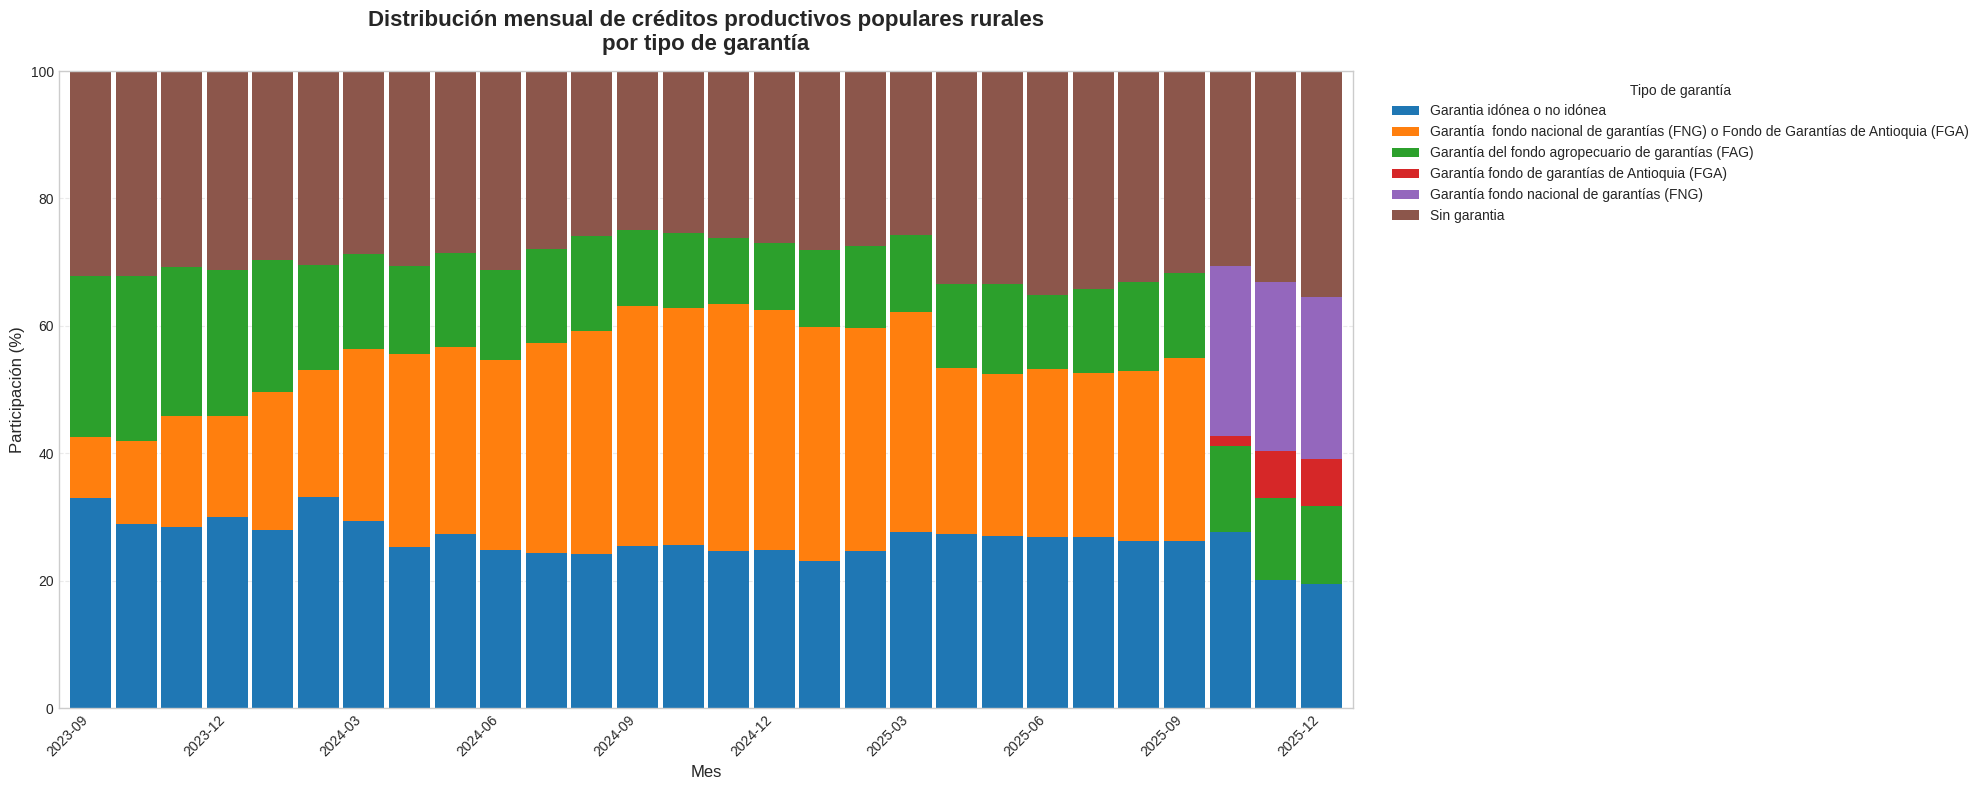

In [ ]:
import matplotlib.pyplot as plt

# Copia limpia
df = df_productivo_popular_rural.copy()
df["year_month_str"] = df["year_month"].astype(str)

# 1) Conteo por mes y tipo de garantía
counts = (
    df.groupby(["year_month_str", "tipo_de_garant_a"])
      .size()
      .reset_index(name="n")
)

# 2) Pivot: filas = mes, columnas = tipo de garantía
pivot = (
    counts.pivot(index="year_month_str",
                 columns="tipo_de_garant_a",
                 values="n")
          .fillna(0)
          .sort_index()
)

# 3) Normalizar al 100% por mes
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# 4) Plot barras apiladas
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(20, 8))

proportions.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.9
)

# 5) Estética académica
ax.set_title(
    "Distribución mensual de créditos productivos populares rurales\npor tipo de garantía",
    fontsize=16,
    weight="bold",
    pad=15
)

ax.set_xlabel("Mes", fontsize=12)
ax.set_ylabel("Participación (%)", fontsize=12)

# Eje Y fijo 0–100
ax.set_ylim(0, 100)

# Grid solo horizontal
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.grid(axis="x", visible=False)

# Submuestreo eje X (cada 3 meses)
xticks = proportions.index[::3]
ax.set_xticks(range(len(proportions.index)))
ax.set_xticklabels(
    [m if m in xticks else "" for m in proportions.index],
    rotation=45,
    ha="right"
)

# Leyenda fuera
ax.legend(
    title="Tipo de garantía",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Crédito Productivo Urbano

In [ ]:
df_productivo_urbano = df_credito_productivo[df_credito_productivo['producto_de_credito_red'] == 'Crédito productivo urbano']

In [ ]:
gap_productivo_urbano = ibc_gap_table(df_productivo_urbano, time_col="year_month",
                    rate_col="tasa_efectiva_promedio",
                    weight_col="numero_de_creditos")
# Columnas clave: IBC_all, IBC_sin_garantia, IBC_con_garantia, gap_sin_garantia_%
gap_productivo_urbano

/tmp/ipykernel_1002/2588240463.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[rate_col].astype(float), weights=g["_w"]))
/tmp/ipykernel_1002/2588240463.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[rate_col].astype(float), weights=g["_w"]))
/tmp/ipykernel_1002/2588240463.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the

,year_month,IBC_all,IBC_sin_garantia,IBC_con_garantia,IBC_rural_sin_garantia,gap_sin_garantia_%
0,2023-09,32.866887,9.921730,40.743020,9.272044,-69.812384
1,2023-10,35.275979,14.661678,41.667889,14.242671,-58.437218
2,2023-11,35.786824,17.163077,41.880119,16.265451,-52.040792
3,2023-12,34.822049,16.108658,41.712264,15.499410,-53.740063
4,2024-01,35.848276,15.314596,44.194738,14.911375,-57.279406
5,2024-02,37.254767,14.496628,43.917856,14.419021,-61.087857
6,2024-03,36.913060,14.069877,43.412840,13.892265,-61.883743
7,2024-04,37.127900,13.767845,43.726279,13.559456,-62.917791
8,2024-05,36.458742,13.498015,43.283849,13.181327,-62.977288
9,2024-06,37.205637,13.080810,44.054758,12.819130,-64.841860


In [ ]:
diag_productivo_urbano = low_rate_cohort_diagnostics(df_productivo_urbano, q=0.25,  # cambia a 0.20 o 0.30 si prefieres
                                   time_col="year_month",
                                   rate_col="tasa_efectiva_promedio",
                                   weight_col="montos_desembolsados")
# reporta: umbral (threshold_q), % peso low-rate, % con garantía dentro de low-rate, % rural, etc.


/tmp/ipykernel_1002/1973752244.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  threshold_result = grouped_f.apply(lambda g: weighted_quantile(g[rate_col], q, g["_w"]))
/tmp/ipykernel_1002/1973752244.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = f.groupby(time_col, as_index=False).apply(_agg)


In [ ]:
share_g_productivo_urbano = (
    df_productivo_urbano.groupby("year_month")
      .apply(lambda g: np.average(g["garantia_flag"], weights=g["montos_desembolsados"]))
      .reset_index(name="share_con_garantia")
)

/tmp/ipykernel_1002/1134137997.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["garantia_flag"], weights=g["montos_desembolsados"]))


#### Plots

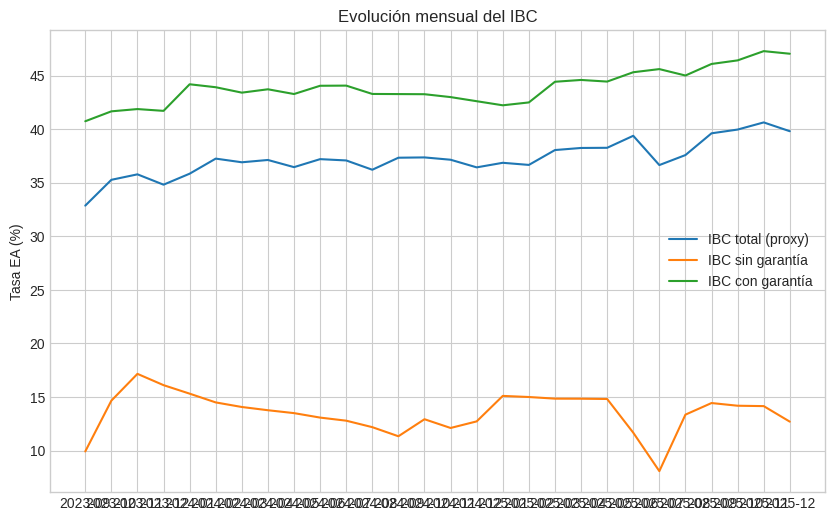

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

gap_productivo_urbano['year_month'] = gap_productivo_urbano['year_month'].astype(str)

plt.figure(figsize=(10,6))
plt.plot(gap_productivo_urbano["year_month"], gap_productivo_urbano["IBC_all"], label="IBC total (proxy)")
plt.plot(gap_productivo_urbano["year_month"], gap_productivo_urbano["IBC_sin_garantia"], label="IBC sin garantía")
plt.plot(gap_productivo_urbano["year_month"], gap_productivo_urbano["IBC_con_garantia"], label="IBC con garantía")
plt.legend()
plt.ylabel("Tasa EA (%)")
plt.title("Evolución mensual del IBC")
plt.show()

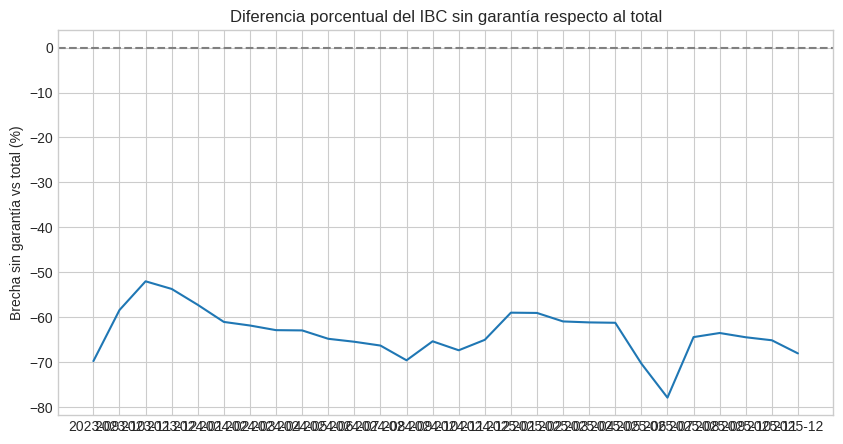

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(gap_productivo_urbano["year_month"], gap_productivo_urbano["gap_sin_garantia_%"])
plt.axhline(0, color="gray", linestyle="--")
plt.ylabel("Brecha sin garantía vs total (%)")
plt.title("Diferencia porcentual del IBC sin garantía respecto al total")
plt.show()

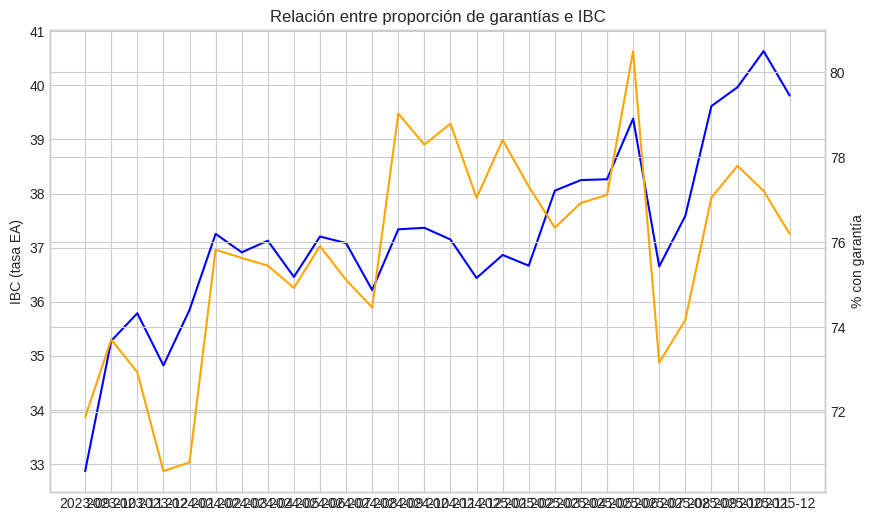

In [ ]:
share_g_productivo_urbano['year_month'] = share_g_productivo_urbano['year_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(10,6))
ax1.plot(gap_productivo_urbano["year_month"], gap_productivo_urbano["IBC_all"], label="IBC total", color="blue")
ax2 = ax1.twinx()
ax2.plot(share_g_productivo_urbano["year_month"], share_g_productivo_urbano["share_con_garantia"]*100, color="orange", label="% con garantía")
ax1.set_ylabel("IBC (tasa EA)"); ax2.set_ylabel("% con garantía")
plt.title("Relación entre proporción de garantías e IBC")
plt.show()

/tmp/ipykernel_1002/403477216.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.ylabel("% del cohort"); plt.title("Composición del cohort de tasas bajas")


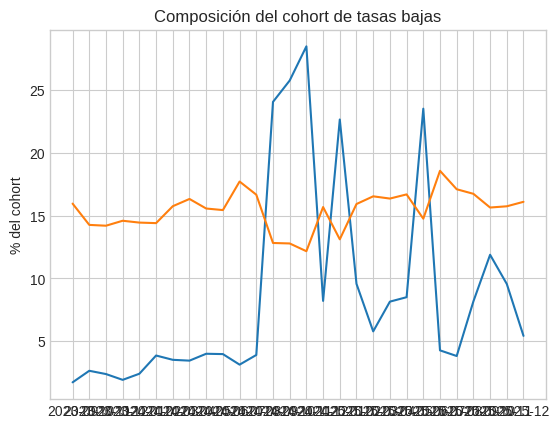

In [ ]:
diag_productivo_urbano['year_month'] = diag_productivo_urbano['year_month'].astype(str)

plt.plot(diag_productivo_urbano["year_month"], diag_productivo_urbano["share_garantia_low_rate_%"])
plt.plot(diag_productivo_urbano["year_month"], diag_productivo_urbano["share_rural_low_rate_%"])
plt.legend(); plt.ylabel("% del cohort"); plt.title("Composición del cohort de tasas bajas")
plt.show()

### Crédito Productivo Popular Urbano

In [ ]:
df_productivo_popular_urbano = df_credito_productivo[df_credito_productivo['producto_de_credito_red'] == 'Crédito popular productivo urbano']

In [ ]:
gap_productivo_popular_urbano = ibc_gap_table(df_productivo_popular_urbano, time_col="year_month",
                    rate_col="tasa_efectiva_promedio",
                    weight_col="numero_de_creditos")
# Columnas clave: IBC_all, IBC_sin_garantia, IBC_con_garantia, gap_sin_garantia_%
gap_productivo_popular_urbano

/tmp/ipykernel_1002/2588240463.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[rate_col].astype(float), weights=g["_w"]))
/tmp/ipykernel_1002/2588240463.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[rate_col].astype(float), weights=g["_w"]))
/tmp/ipykernel_1002/2588240463.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the

,year_month,IBC_all,IBC_sin_garantia,IBC_con_garantia,IBC_rural_sin_garantia,gap_sin_garantia_%
0,2023-09,47.341963,14.036854,49.371511,12.947692,-70.350081
1,2023-10,48.115427,28.936281,49.581578,25.084190,-39.860700
2,2023-11,48.132030,28.794065,49.465536,24.717682,-40.176915
3,2023-12,47.902455,25.881421,49.428656,22.292496,-45.970576
4,2024-01,51.640205,19.170243,53.600209,17.362866,-62.877291
5,2024-02,54.104780,14.491245,55.852206,14.422992,-73.216331
6,2024-03,57.559500,13.841910,59.366439,13.819068,-75.951998
7,2024-04,58.204173,13.262700,59.948790,13.382805,-77.213490
8,2024-05,58.422785,13.634780,60.239268,13.519956,-76.661879
9,2024-06,59.645985,13.075195,61.355941,12.892792,-78.078666


In [ ]:
diag_productivo_popular_urbano = low_rate_cohort_diagnostics(df_productivo_popular_urbano, q=0.25,  # cambia a 0.20 o 0.30 si prefieres
                                   time_col="year_month",
                                   rate_col="tasa_efectiva_promedio",
                                   weight_col="montos_desembolsados")
# reporta: umbral (threshold_q), % peso low-rate, % con garantía dentro de low-rate, % rural, etc.


/tmp/ipykernel_1002/1973752244.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  threshold_result = grouped_f.apply(lambda g: weighted_quantile(g[rate_col], q, g["_w"]))
/tmp/ipykernel_1002/1973752244.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = f.groupby(time_col, as_index=False).apply(_agg)


In [ ]:
share_g_productivo_popular_urbano = (
    df_productivo_popular_urbano.groupby("year_month")
      .apply(lambda g: np.average(g["garantia_flag"], weights=g["montos_desembolsados"]))
      .reset_index(name="share_con_garantia")
)

/tmp/ipykernel_1002/3768071958.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["garantia_flag"], weights=g["montos_desembolsados"]))


#### Plots

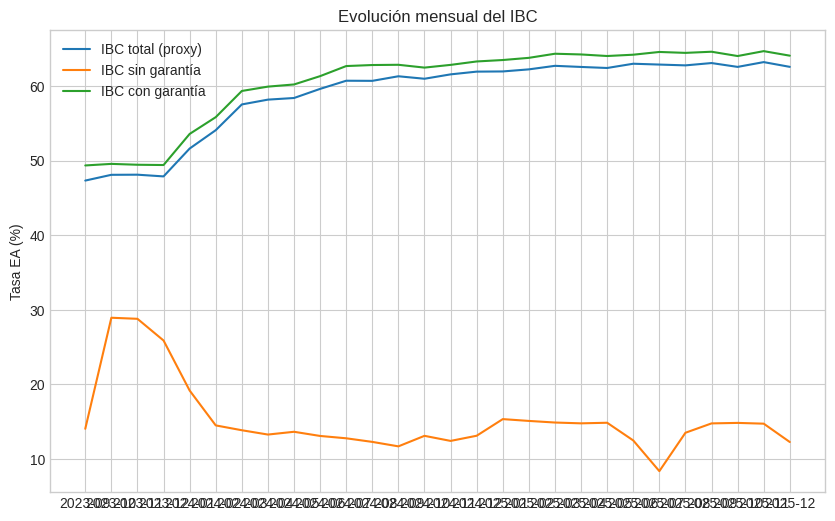

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

gap_productivo_popular_urbano['year_month'] = gap_productivo_popular_urbano['year_month'].astype(str)

plt.figure(figsize=(10,6))
plt.plot(gap_productivo_popular_urbano["year_month"], gap_productivo_popular_urbano["IBC_all"], label="IBC total (proxy)")
plt.plot(gap_productivo_popular_urbano["year_month"], gap_productivo_popular_urbano["IBC_sin_garantia"], label="IBC sin garantía")
plt.plot(gap_productivo_popular_urbano["year_month"], gap_productivo_popular_urbano["IBC_con_garantia"], label="IBC con garantía")
plt.legend()
plt.ylabel("Tasa EA (%)")
plt.title("Evolución mensual del IBC")
plt.show()

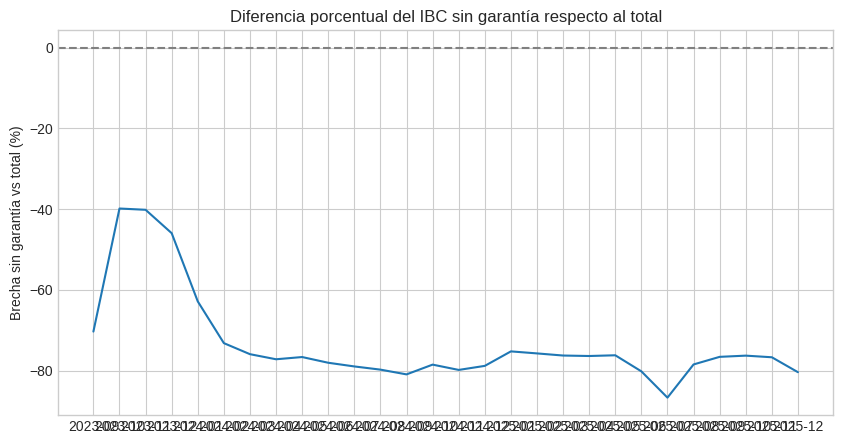

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(gap_productivo_popular_urbano["year_month"], gap_productivo_popular_urbano["gap_sin_garantia_%"])
plt.axhline(0, color="gray", linestyle="--")
plt.ylabel("Brecha sin garantía vs total (%)")
plt.title("Diferencia porcentual del IBC sin garantía respecto al total")
plt.show()

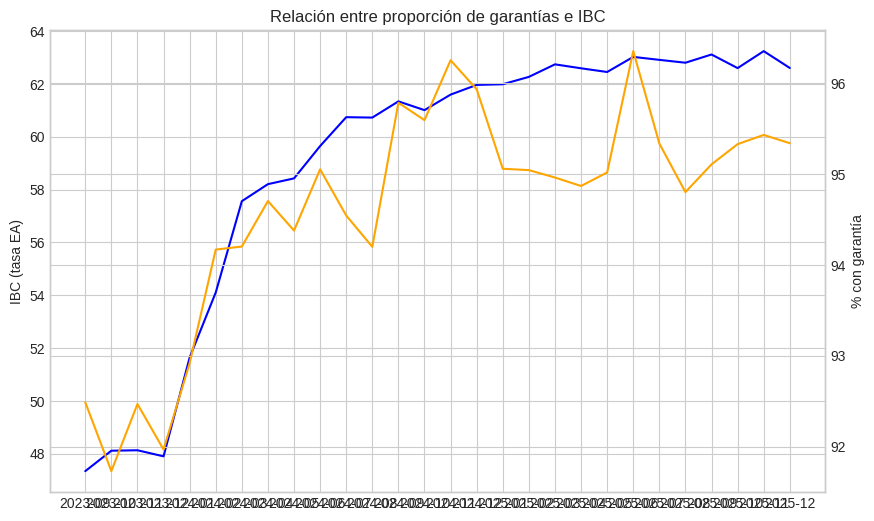

In [ ]:
share_g_productivo_popular_urbano['year_month'] = share_g_productivo_popular_urbano['year_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(10,6))
ax1.plot(gap_productivo_popular_urbano["year_month"], gap_productivo_popular_urbano["IBC_all"], label="IBC total", color="blue")
ax2 = ax1.twinx()
ax2.plot(share_g_productivo_popular_urbano["year_month"], share_g_productivo_popular_urbano["share_con_garantia"]*100, color="orange", label="% con garantía")
ax1.set_ylabel("IBC (tasa EA)"); ax2.set_ylabel("% con garantía")
plt.title("Relación entre proporción de garantías e IBC")
plt.show()

/tmp/ipykernel_1002/3990199249.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.ylabel("% del cohort"); plt.title("Composición del cohort de tasas bajas")


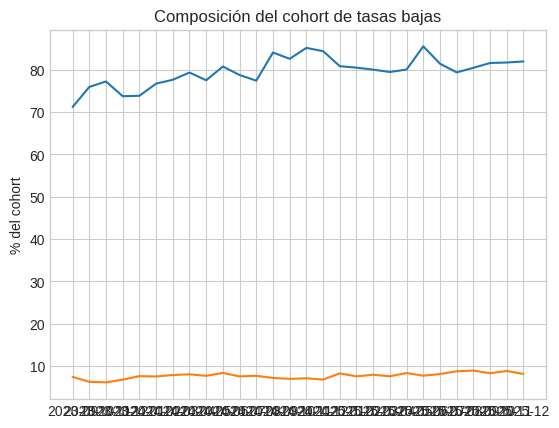

In [ ]:
diag_productivo_popular_urbano['year_month'] = diag_productivo_popular_urbano['year_month'].astype(str)

plt.plot(diag_productivo_popular_urbano["year_month"], diag_productivo_popular_urbano["share_garantia_low_rate_%"])
plt.plot(diag_productivo_popular_urbano["year_month"], diag_productivo_popular_urbano["share_rural_low_rate_%"])
plt.legend(); plt.ylabel("% del cohort"); plt.title("Composición del cohort de tasas bajas")
plt.show()

In [ ]:
diag_productivo_popular_urbano

,year_month,threshold_q,share_low_rate_%,rate_avg_low_rate,share_garantia_low_rate_%,share_rural_low_rate_%
0,2023-09,46.49,25.354410,28.853709,71.207229,7.387872
1,2023-10,48.50,25.550926,33.434073,75.957573,6.219987
2,2023-11,47.85,25.212181,33.802656,77.249722,6.098432
3,2023-12,45.85,25.086325,32.327192,73.767444,6.730495
4,2024-01,49.04,25.494281,34.914104,73.865197,7.562383
5,2024-02,49.67,25.060237,33.157691,76.732277,7.481098
6,2024-03,51.73,25.947714,33.429994,77.658253,7.826896
7,2024-04,51.15,25.658136,33.492731,79.357284,7.997203
8,2024-05,47.98,25.020947,32.541321,77.532721,7.634076
9,2024-06,51.99,25.746750,35.157846,80.786215,8.323880
